**Exploración de distribuciones de colores y texturas de UTKFace**


* Extraemos características de color: RGB, escala de grises, y HSV (Matiz y Saturación)
* Extraemos características de textura: Local Binary Patterns (LBP) con diferentes configuraciones

Agrupamos los resultados por:

* Género (Masculino/Femenino)
* Edad (0-14, 15-30, 31-50, 51+)
* Raza (White, Black, Asian, Indian, Others)



In [1]:
import os, glob, re, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
from tqdm import tqdm
from skimage.feature import local_binary_pattern


In [2]:
ImageFile.LOAD_TRUNCATED_IMAGES = True
IMG_DIR   = "/kaggle/input/utkface-new/UTKFace"  # <-- change this path
EXTS      = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff")
BINS      = 256
DTYPE     = np.int64

NORMALIZE = True      # True => plots show probabilities
DO_HSV    = True
DO_LBP    = True

# Save figures (optional)
SAVE_FIGS = False
SAVE_DIR  = "./utkface_plots"
os.makedirs(SAVE_DIR, exist_ok=True) if SAVE_FIGS else None

# Age bins (inclusive) for grouping
AGE_BINS = [
    ("0–14",   0, 14),
    ("15–30",  15, 30),
    ("31–50",  31, 50),
    ("51+",    51, 200),
]

# Race labels per UTKFace spec
RACE_LABELS = {
    0: "White",
    1: "Black",
    2: "Asian",
    3: "Indian",
    4: "Others",  # Hispanic/Latino/Middle Eastern, etc.
}

# LBP settings (Uniform LBP)
LBP_SETTINGS = [
    {"P": 8,  "R": 1.0},
    {"P": 16, "R": 2.0},
]

In [3]:
def iter_image_paths(root, exts):
    for ext in exts:
        yield from glob.iglob(os.path.join(root, "**", ext), recursive=True)

def load_rgb(path):
    with Image.open(path) as im:
        return np.asarray(im.convert("RGB"), dtype=np.uint8)

def bincount_256(channel_uint8):
    return np.bincount(channel_uint8.ravel(), minlength=256).astype(DTYPE)

def parse_age_gender_race_from_name(fname):
    """
    UTKFace: age_gender_race_date[...].jpg
    age: 0..116 (int)
    gender: 0=male,1=female
    race: 0..4
    """
    base = os.path.basename(fname)
    parts = re.split(r"_", base)
    if len(parts) < 3:
        return None, None, None
    def _toi(s):
        m = re.match(r"(\d+)", s)
        return int(m.group(1)) if m else None
    age    = _toi(parts[0])
    gender = _toi(parts[1])
    race   = _toi(parts[2])
    if gender not in (0, 1): gender = None
    if race not in (0, 1, 2, 3, 4): race = None
    return age, gender, race

def age_bucket_label(age):
    if age is None:
        return None
    for label, lo, hi in AGE_BINS:
        if lo <= age <= hi:
            return label
    return None

def rgb_to_hsv_uint8(rgb):
    """Vectorized RGB->HSV, returns uint8 H,S,V in [0,255]; here we only use H,S."""
    rgbf = rgb.astype(np.float32) / 255.0
    r, g, b = rgbf[..., 0], rgbf[..., 1], rgbf[..., 2]
    cmax = rgbf.max(axis=-1)
    cmin = rgbf.min(axis=-1)
    delta = cmax - cmin

    hue = np.zeros_like(cmax)
    mask = delta > 1e-6
    idx = (cmax == r) & mask
    hue[idx] = (60 * ((g[idx] - b[idx]) / delta[idx]) + 360) % 360
    idx = (cmax == g) & mask
    hue[idx] = (60 * ((b[idx] - r[idx]) / delta[idx]) + 120) % 360
    idx = (cmax == b) & mask
    hue[idx] = (60 * ((r[idx] - g[idx]) / delta[idx]) + 240) % 360

    sat = np.zeros_like(cmax)
    nz = cmax > 0
    sat[nz] = delta[nz] / cmax[nz]
    val = cmax

    hsv = np.empty_like(rgbf)
    hsv[..., 0] = hue / 360.0
    hsv[..., 1] = sat
    hsv[..., 2] = val
    return (hsv * 255.0).astype(np.uint8)

def norm_or_counts(arr, denom=None):
    if not NORMALIZE:
        return arr
    if denom is None:
        denom = max(arr.sum(), 1)
    return arr.astype(np.float64) / max(denom, 1)

def new_group_accumulator():
    d = {
        "R": np.zeros(BINS, dtype=DTYPE),
        "G": np.zeros(BINS, dtype=DTYPE),
        "B": np.zeros(BINS, dtype=DTYPE),
        "Gray": np.zeros(BINS, dtype=DTYPE),
        "count": 0,
    }
    if DO_HSV:
        d["H"] = np.zeros(BINS, dtype=DTYPE)
        d["S"] = np.zeros(BINS, dtype=DTYPE)
    if DO_LBP:
        d["LBP"] = [np.zeros(s["P"] + 2, dtype=DTYPE) for s in LBP_SETTINGS]
    return d

In [4]:
hist_R    = np.zeros(BINS, dtype=DTYPE)
hist_G    = np.zeros(BINS, dtype=DTYPE)
hist_B    = np.zeros(BINS, dtype=DTYPE)
hist_gray = np.zeros(BINS, dtype=DTYPE)

if DO_HSV:
    hist_H = np.zeros(BINS, dtype=DTYPE)
    hist_S = np.zeros(BINS, dtype=DTYPE)

if DO_LBP:
    lbp_hists_overall = [np.zeros(s["P"] + 2, dtype=DTYPE) for s in LBP_SETTINGS]

# Groups
gender_groups = {"Male": new_group_accumulator(), "Female": new_group_accumulator()}
age_groups    = {label: new_group_accumulator() for (label, _, _) in AGE_BINS}
race_groups   = {label: new_group_accumulator() for label in RACE_LABELS.values()}

In [5]:
n_ok, n_fail = 0, 0

for p in tqdm(iter_image_paths(IMG_DIR, EXTS), total=23708, desc="Processing images"):
    try:
        arr = load_rgb(p)
        R, G, B = arr[..., 0], arr[..., 1], arr[..., 2]
        Y = (0.299*R + 0.587*G + 0.114*B).astype(np.uint8)

        # Overall RGB + Gray
        r_hist = bincount_256(R); hist_R += r_hist
        g_hist = bincount_256(G); hist_G += g_hist
        b_hist = bincount_256(B); hist_B += b_hist
        y_hist = bincount_256(Y); hist_gray += y_hist

        # Overall HSV
        if DO_HSV:
            hsv = rgb_to_hsv_uint8(arr)
            H, S = hsv[..., 0], hsv[..., 1]
            h_hist = bincount_256(H); hist_H += h_hist
            s_hist = bincount_256(S); hist_S += s_hist
        else:
            h_hist = s_hist = None

        # Overall LBP
        if DO_LBP:
            for i, s in enumerate(LBP_SETTINGS):
                lbp = local_binary_pattern(Y, P=s["P"], R=s["R"], method="uniform").astype(np.uint16)
                lbp_hists_overall[i] += np.bincount(lbp.ravel(), minlength=s["P"] + 2).astype(DTYPE)

        # Parse groups
        age, gender, race = parse_age_gender_race_from_name(p)

        # Update per-group accumulators
        def upd(group_dict, key):
            g = group_dict[key]
            g["R"]    += r_hist
            g["G"]    += g_hist
            g["B"]    += b_hist
            g["Gray"] += y_hist
            if DO_HSV:
                g["H"] += h_hist
                g["S"] += s_hist
            if DO_LBP:
                for i, s in enumerate(LBP_SETTINGS):
                    lbp = local_binary_pattern(Y, P=s["P"], R=s["R"], method="uniform").astype(np.uint16)
                    g["LBP"][i] += np.bincount(lbp.ravel(), minlength=s["P"] + 2).astype(DTYPE)
            g["count"] += 1

        if gender in (0, 1):
            gkey = "Male" if gender == 0 else "Female"
            upd(gender_groups, gkey)

        ab = age_bucket_label(age)
        if ab is not None:
            upd(age_groups, ab)

        if race in RACE_LABELS:
            rkey = RACE_LABELS[race]
            upd(race_groups, rkey)

        n_ok += 1
    except Exception:
        n_fail += 1

print(f"Processed {n_ok} images. Failed: {n_fail}")
print("Gender counts:", {k: v["count"] for k, v in gender_groups.items()})
print("Age counts:",    {k: v["count"] for k, v in age_groups.items()})
print("Race counts:",   {k: v["count"] for k, v in race_groups.items()})

Processing images: 100%|██████████| 23708/23708 [44:19<00:00,  8.91it/s]

Processed 23708 images. Failed: 0
Gender counts: {'Male': 12391, 'Female': 11317}
Age counts: {'0–14': 3651, '15–30': 9010, '31–50': 6439, '51+': 4608}
Race counts: {'White': 10078, 'Black': 4526, 'Asian': 3434, 'Indian': 3975, 'Others': 1692}


In [6]:
# Prep for plotting (overall)
x = np.arange(BINS)

def rgb_plots_from_hists(r, g, b):
    denom = (r + g + b).sum() / 3.0 if NORMALIZE else None
    return norm_or_counts(r, denom), norm_or_counts(g, denom), norm_or_counts(b, denom)

R_plot, G_plot, B_plot = rgb_plots_from_hists(hist_R, hist_G, hist_B)
Gray_plot = norm_or_counts(hist_gray, hist_gray.sum() if NORMALIZE else None)

if DO_HSV:
    H_plot = norm_or_counts(hist_H, hist_H.sum() if NORMALIZE else None)
    S_plot = norm_or_counts(hist_S, hist_S.sum() if NORMALIZE else None)

if DO_LBP:
    LBP_plots_overall = [norm_or_counts(h, h.sum() if NORMALIZE else None)
                         for h in lbp_hists_overall]


In [7]:
# prepare group plots

def prep_group_component(groups, key, denom_kind="auto"):
    """
    Returns {name: hist_for_plot} for a scalar 256-bin component (Gray/H/S).
    denom_kind:
      - "auto": use sum of the component
      - number (float): shared denom for all groups
      - None: raw counts
    """
    out = {}
    for name, d in groups.items():
        h = d[key]
        if not NORMALIZE:
            out[name] = h
        else:
            if denom_kind == "auto":
                out[name] = norm_or_counts(h, h.sum())
            elif isinstance(denom_kind, (int, float)):
                out[name] = norm_or_counts(h, denom_kind)
            else:
                out[name] = h
    return out

def prep_group_rgb(groups):
    """
    Returns {name: {'R','G','B'}} with per-group normalization based on that group's RGB totals.
    """
    out = {}
    for name, d in groups.items():
        if NORMALIZE:
            denom = (d["R"] + d["G"] + d["B"]).sum() / 3.0
        else:
            denom = None
        out[name] = {
            "R": norm_or_counts(d["R"], denom),
            "G": norm_or_counts(d["G"], denom),
            "B": norm_or_counts(d["B"], denom),
        }
    return out

def prep_group_lbp(groups):
    """
    Returns a list (per LBP setting) of dicts: [{group_name: hist}, ...]
    """
    if not DO_LBP:
        return []
    outs = []
    for i, s in enumerate(LBP_SETTINGS):
        setting_dict = {}
        for name, d in groups.items():
            h = d["LBP"][i]
            setting_dict[name] = norm_or_counts(h, h.sum() if NORMALIZE else None)
        outs.append(setting_dict)
    return outs

# Prepared structures
gender_rgb      = prep_group_rgb(gender_groups)
age_rgb         = prep_group_rgb(age_groups)
race_rgb        = prep_group_rgb(race_groups)

gender_gray     = prep_group_component(gender_groups, "Gray", "auto")
age_gray        = prep_group_component(age_groups, "Gray", "auto")
race_gray       = prep_group_component(race_groups, "Gray", "auto")

if DO_HSV:
    gender_h = prep_group_component(gender_groups, "H", "auto")
    age_h    = prep_group_component(age_groups,    "H", "auto")
    race_h   = prep_group_component(race_groups,   "H", "auto")

    gender_s = prep_group_component(gender_groups, "S", "auto")
    age_s    = prep_group_component(age_groups,    "S", "auto")
    race_s   = prep_group_component(race_groups,   "S", "auto")

if DO_LBP:
    gender_lbp = prep_group_lbp(gender_groups)
    age_lbp    = prep_group_lbp(age_groups)
    race_lbp   = prep_group_lbp(race_groups)

In [8]:
## RGB
df_rgb = pd.DataFrame(list(zip(R_plot, G_plot, B_plot)), columns=['Red', 'Green', 'Blue'])
df_rgb.to_csv("rgb.csv", index=False)

df_gender_rgb = pd.concat(
    {sex: pd.DataFrame({ch: np.asarray(vals) for ch, vals in channels.items()})
     for sex, channels in gender_rgb.items()},
    axis=1
)
df_gender_rgb.to_csv("rgb_gender.csv", index=False)

df_age_rgb = pd.concat(
    {age: pd.DataFrame({ch: np.asarray(vals) for ch, vals in channels.items()})
     for age, channels in age_rgb.items()},
    axis=1
)
df_age_rgb.to_csv("rgb_age.csv", index=False)
df_race_rgb = pd.concat(
    {race: pd.DataFrame({ch: np.asarray(vals) for ch, vals in channels.items()})
     for race, channels in race_rgb.items()},
    axis=1
)
df_race_rgb.to_csv("rgb.csv_race", index=False)

In [9]:
df_saturation = pd.DataFrame(S_plot, columns=['Saturation'])
df_saturation.to_csv("saturation.csv", index=False)

df_race_saturation = pd.DataFrame(list(zip(*list(race_s.values()))),  columns=list(race_s.keys()))
df_race_saturation.to_csv("saturation_race.csv", index=False)

df_age_saturation = pd.DataFrame(list(zip(*list(age_s.values()))),  columns=list(age_s.keys()))
df_age_saturation.to_csv("saturation_age.csv", index=False)

df_gender_saturation = pd.DataFrame(list(zip(*list(gender_s.values()))),  columns=list(gender_s.keys()))
df_gender_saturation.to_csv("saturation_gender.csv", index=False)

In [10]:
df_grayscale = pd.DataFrame(Gray_plot, columns=['grayscale'])
df_grayscale.to_csv("grayscale.csv", index=False)

df_race_grayscale = pd.DataFrame(list(zip(*list(race_gray.values()))),  columns=list(race_gray.keys()))
df_race_grayscale.to_csv("grayscale_race.csv", index=False)

df_age_grayscale = pd.DataFrame(list(zip(*list(age_gray.values()))),  columns=list(age_gray.keys()))
df_age_grayscale.to_csv("grayscale_age.csv", index=False)

df_gender_grayscale = pd.DataFrame(list(zip(*list(gender_gray.values()))),  columns=list(gender_gray.keys()))
df_gender_grayscale.to_csv("grayscale_gender.csv", index=False)

In [11]:
df_hue = pd.DataFrame(Gray_plot, columns=['hue'])
df_hue.to_csv("hue.csv", index=False)

df_race_hue = pd.DataFrame(list(zip(*list(race_h.values()))),  columns=list(race_h.keys()))
df_race_hue.to_csv("hue_race.csv", index=False)

df_age_hue = pd.DataFrame(list(zip(*list(age_h.values()))),  columns=list(age_h.keys()))
df_age_hue.to_csv("hue_age.csv", index=False)

df_gender_hue = pd.DataFrame(list(zip(*list(gender_h.values()))),  columns=list(gender_h.keys()))
df_gender_hue.to_csv("hue_gender.csv", index=False)

In [12]:
for i in range(len(LBP_SETTINGS)):
    tag = "_".join([f"{k}_{v}" for k,v in LBP_SETTINGS[i].items()]).replace(".0","") 
    df = pd.DataFrame(LBP_plots_overall[i], columns=["lbp"])
    df.to_csv("lbp_" + tag + ".csv", index=False)
    df_race_lbp = pd.DataFrame(list(zip(*list(race_lbp[i].values()))),  columns=list(race_lbp[i].keys()))
    df_race_lbp.to_csv("lbp_race_" + tag + ".csv", index=False)
    df_age_lbp = pd.DataFrame(list(zip(*list(age_lbp[i].values()))),  columns=list(age_lbp[i].keys()))
    df_age_lbp.to_csv("lbp_age_" + tag + ".csv", index=False)
    df_gender_lbp = pd.DataFrame(list(zip(*list(gender_lbp[i].values()))),  columns=list(gender_lbp[i].keys()))
    df_gender_lbp.to_csv("lbp_gender_" + tag + ".csv", index=False)
    

In [13]:
def save_show(name):
    if SAVE_FIGS:
        plt.savefig(os.path.join(SAVE_DIR, f"{name}.png"), dpi=150, bbox_inches="tight")
    plt.show()

def plot_rgb_dataset():
    plt.figure(figsize=(9, 4))
    plt.plot(x, R_plot, label="Red", alpha=0.9, color="red")
    plt.plot(x, G_plot, label="Green", alpha=0.9, color="green")
    plt.plot(x, B_plot, label="Blue", alpha=0.9, color="blue")
    plt.title("RGB histogram – Dataset")
    plt.xlabel("Pixel value")
    plt.ylabel("Probability" if NORMALIZE else "Count")
    plt.legend(); plt.tight_layout()
    save_show("dataset_rgb")

def plot_rgb_by_group(groups_rgb, title_prefix):
    # Grid: one subplot per group, showing RGB curves
    n = len(groups_rgb)
    cols = min(3, n)
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(4*cols, 3.2*rows))
    for i, (name, rgb) in enumerate(groups_rgb.items(), start=1):
        plt.subplot(rows, cols, i)
        plt.plot(x, rgb["R"], label="Red",   alpha=0.9, color="red")
        plt.plot(x, rgb["G"], label="Green", alpha=0.9, color="green")
        plt.plot(x, rgb["B"], label="Blue",  alpha=0.9, color="blue")
        plt.title(name)
        if i > (rows-1)*cols: plt.xlabel("Pixel value")
        if i % cols == 1:     plt.ylabel("Probability" if NORMALIZE else "Count")
    plt.suptitle(f"RGB histograms – {title_prefix}", y=1.02)
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.05, 1.0))
    save_show(f"rgb_by_{title_prefix.lower().replace(' ', '_')}")

def plot_channel_overlay(groups_rgb, channel, title_prefix):
    plt.figure(figsize=(9, 4))
    for name, rgb in groups_rgb.items():
        plt.plot(x, rgb[channel], label=name, alpha=0.9)
    plt.title(f"{channel}-channel histogram – {title_prefix}")
    plt.xlabel("Pixel value")
    plt.ylabel("Probability" if NORMALIZE else "Count")
    plt.legend(); plt.tight_layout()
    save_show(f"{channel.lower()}_overlay_{title_prefix.lower().replace(' ', '_')}")

def plot_scalar_dataset(arr, title, ylabel_name, fname):
    plt.figure(figsize=(9, 4))
    plt.plot(x, arr, alpha=0.95)
    plt.title(title)
    plt.xlabel("Value (0–255)")
    plt.ylabel(ylabel_name)
    plt.tight_layout()
    save_show(fname)

def plot_scalar_by_group(groups_scalar, title_prefix, ylabel_name, fname_prefix):
    plt.figure(figsize=(9, 4))
    for name, h in groups_scalar.items():
        plt.plot(x, h, label=name, alpha=0.9)
    plt.title(f"{title_prefix}")
    plt.xlabel("Value (0–255)")
    plt.ylabel(ylabel_name)
    plt.legend(); plt.tight_layout()
    save_show(fname_prefix)

def plot_lbp_dataset(lbp_plots, settings):
    for i, (h, s) in enumerate(zip(lbp_plots, settings), start=1):
        plt.figure(figsize=(9, 4))
        plt.plot(np.arange(len(h)), h, alpha=0.95)
        plt.title(f"LBP histogram – Dataset (P={s['P']}, R={s['R']})")
        plt.xlabel("LBP code (uniform)")
        plt.ylabel("Probability" if NORMALIZE else "Count")
        plt.tight_layout()
        save_show(f"lbp_dataset_P{s['P']}_R{s['R']}")

def plot_lbp_by_group(groups_lbp, settings, title_prefix, fname_prefix):
    for i, s in enumerate(settings):
        plt.figure(figsize=(9, 4))
        for name, hist in groups_lbp[i].items():
            plt.plot(np.arange(len(hist)), hist, label=name, alpha=0.9)
        plt.title(f"LBP histogram – {title_prefix} (P={s['P']}, R={s['R']})")
        plt.xlabel("LBP code (uniform)")
        plt.ylabel("Probability" if NORMALIZE else "Count")
        plt.legend(); plt.tight_layout()
        save_show(f"{fname_prefix}_P{s['P']}_R{s['R']}")

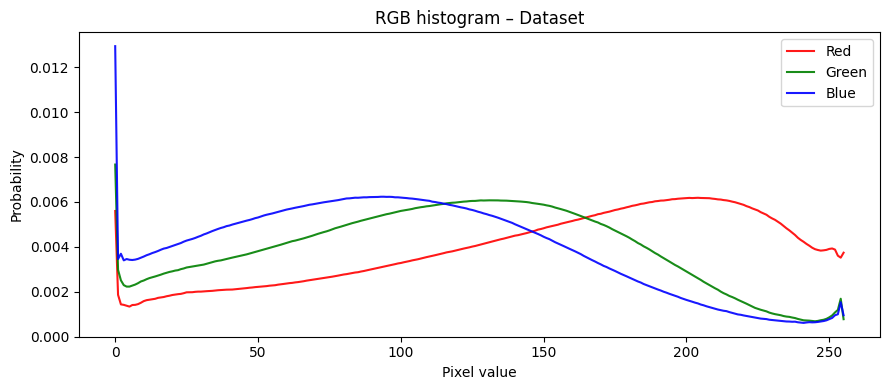

In [14]:

plot_rgb_dataset()

**Interpretación del histograma RGB**

El RGB muestra la distribución de las intensidades de píxeles en los canales rojo, verde y azul del conjunto de datos de imágenes faciales UTKFace. El eje X representa los "valores de píxel" y va de 0 a 255. Este rango corresponde a la intensidad o brillo de cada canal de color en el espacio RGB de 8 bits. Un valor de 0 significa ausencia total de ese color (negro), mientras que 255 significa la máxima intensidad de ese color (completamente saturado). Por ejemplo, en el canal rojo, un píxel con valor 0 no tiene nada de rojo, mientras que uno con valor 255 tiene el máximo rojo posible. Cada píxel de cada imagen del dataset tiene un valor entre 0 y 255 para cada uno de los tres canales (rojo, verde y azul), y el histograma cuenta cuántos píxeles caen en cada uno de estos 256 valores posibles.

El eje Y representa la "probabilidad" de que un pixel tenga ese valor de intensidad en el canal específico, en términos prácticos, cuando vemos que el canal rojo tiene una probabilidad de 0.006 alrededor del valor 180, esto nos dice que el 0.6% de todos los píxeles rojos en el dataset completo tienen una intensidad de aproximadamente 180. El pico dramático cerca de 0 con probabilidad de 0.012 indica que el 1.2% de todos los píxeles son muy oscuros.


 Vemos una alta concentración de valores de píxeles oscuros, especialmente en el rango de 0 a 5 en los tres canales, sobre todo en los canales verde y azul. Esta fuerte presencia de intensidades cercanas al negro sugiere que muchas imágenes contienen fondos oscuros, sombras, cabello, ropa o bordes negros. Estas características son típicas en conjuntos de datos de rostros, donde los sujetos suelen estar centrados y las áreas circundantes permanecen oscuras o subexpuestas. También puede indicar que las imágenes no fueron capturadas en ambientes profesionales (no todas están iluminadas de la misma manera).

El canal azul predomina en los valores de píxel más oscuros, esto sugiere la presencia de sombras de tonos fríos o condiciones de baja luminosidad con tinte azulado, lo que podría deberse a la iluminación interior o al comportamiento de los sensores de las cámaras. Esto indica que, si bien el conjunto de datos contiene muchas áreas oscuras, estas sombras no son puramente neutras ni cálidas, sino que presentan un ligero matiz azulado.En el rango medio de valores de píxeles (hasta aproximadamente 120), el canal azul es el más intenso y el verde tiende a predominar sobre el rojo. Esto sugiere que las áreas neutras y sombreadas del conjunto de datos tienden ligeramente a tonos fríos y que las cámaras capturan la información de luminancia principalmente a través del canal verde.

A medida que el histograma se adentra en el rango de tonos medios (120-150), el canal verde se vuelve el más dominante, con un pico pronunciado alrededor de los valores 130-140. Esto concuerda con la composición cromática natural de la piel humana, donde el verde contribuye significativamente a equilibrar los tonos medios. La forma general sugiere que el conjunto de datos se compone principalmente de tonos de piel naturales y que los colores no están sobresaturados.


Más allá del pico inicial  el canal rojo domina en el rango de 150 a 220 con un pico máximo alrededor de 180-200. Esta característica es altamente consistente con la presencia dominante de tonos de piel humana, que típicamente reflejan más luz roja que verde o azul. El verde, por su parte, mantiene una distribución más uniforme en el rango medio, con un pico secundario alrededor de 100-120, mientras que el azul muestra su máximo en valores medios-bajos (100-120) y decae más rápidamente hacia valores altos, lo que refuerza la presencia de una ligera tendencia hacia los colores cálidos en el conjunto de datos y una menor presencia de elementos azules en las regiones faciales.

Más allá de los valores de intensidad de píxel de 200 y hasta 255, los tres canales muestran una marcada disminución, con un pico mínimo en 255. Esto indica que el conjunto de datos contiene muy pocas áreas brillantes o sobreexpuestas. Hay poca evidencia de altas luces, fondos blancos o regiones deslavadas. Esto implica que el conjunto de datos se compone principalmente de imágenes con iluminación natural y bajo contraste, en lugar de imágenes con alta iluminación o iluminación de estudio.

Por otro lado, se observa un pico menor cerca del valor de píxel 255, que representa píxeles muy brillantes o blancos, como las altas luces de la imagen, los reflejos de la luz en la piel del rostro o los fondos y la ropa blancos.

El conjunto de datos se caracteriza por fondos oscuros y sombras, tonos medios de piel naturales con predominio del verde y el rojo, y una tonalidad cálida debido a la mayor intensidad del rojo en los tonos medios más tenues. Las sombras azuladas son frecuentes en las zonas oscuras, probablemente debido a la iluminación fría ambiental o producida por la cámara. Los reflejos brillantes son mínimos, lo que sugiere que el conjunto de datos evita la iluminación intensa, la alta exposición o los fondos blancos artificiales. El conjunto de datos es realista, con iluminación suave y acorde con las condiciones típicas de la fotografía de rostros.

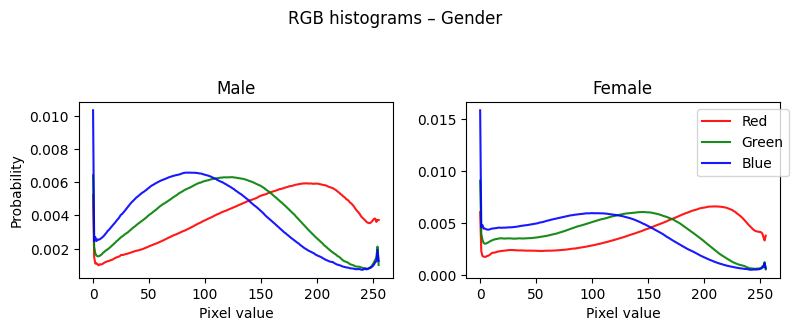

In [15]:
plot_rgb_by_group(gender_rgb, "Gender")

Ambos géneros comparten el pico cerca del valor 0, pero la magnitud de este pico es notablemente más alta en las imágenes femeninas, alcanzando una probabilidad cercana a 0.016 comparada con aproximadamente 0.010 en las masculinas. Esta diferencia sugiere que las fotografías de mujeres en el dataset contienen más píxeles oscuros, lo cual podría atribuirse a la presencia de cabello más largo y oscuro que ocupa una mayor proporción del encuadre fotográfico. Más allá del pico inicial, las distribuciones de los tres canales muestran que los rostros masculinos tienen curvas más amplias y elevadas en los rangos medios y altos, especialmente visible en el canal rojo donde los hombres muestran un pico más pronunciado alrededor de 180-200, mientras que las mujeres tienen una distribución más aplanada y uniforme.

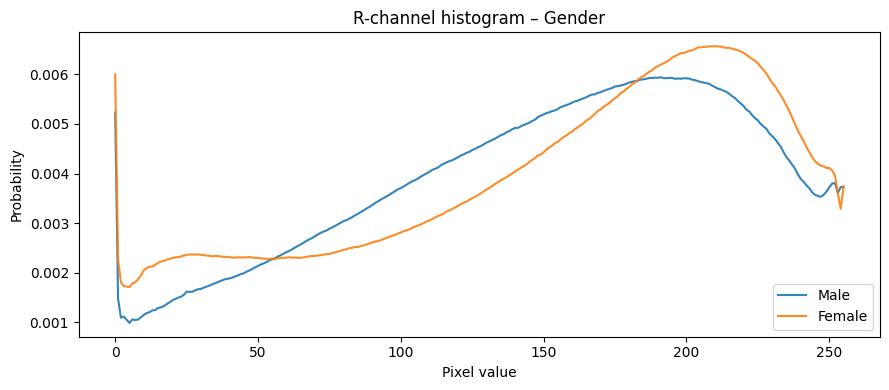

In [16]:
plot_channel_overlay(gender_rgb, "R", "Gender")

La curva masculina (azul) muestra una tendencia ascendente más pronunciada desde valores bajos hacia el pico en la región 180-220, alcanzando una probabilidad máxima de aproximadamente 0.0055. En contraste, la curva femenina (naranja) mantiene una meseta más plana en el rango medio antes de formar un pico más amplio pero menos pronunciado alrededor de 200-220. Esta diferencia morfológica sugiere que los rostros masculinos tienen una distribución de rojos más concentrada, posiblemente debido a diferencias en el grosor de la piel, vascularización facial, o la presencia de vello facial que reduce las áreas de piel expuesta. Las mujeres, por otro lado, muestran una distribución de rojos más dispersa que podría relacionarse con el uso de maquillaje, diferencias en el tono de piel, o simplemente una mayor variabilidad en la iluminación de la piel facial.



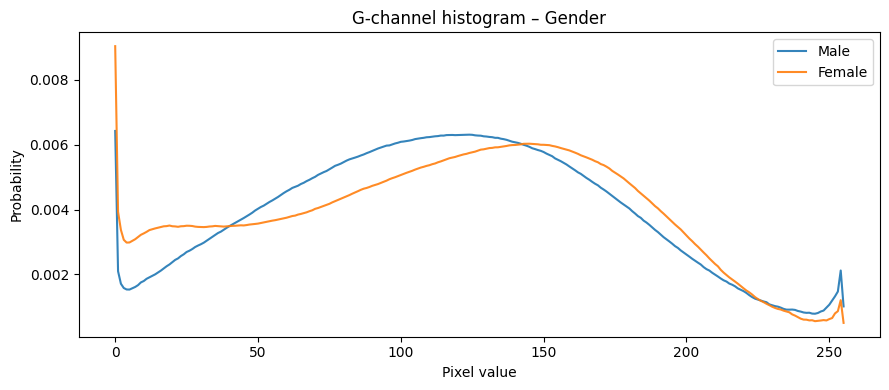

In [17]:
plot_channel_overlay(gender_rgb, "G", "Gender")

El canal verde muestra similitudes y diferencias complementarias entre géneros, ambas curvas exhiben el pico inicial en 0 y luego ascienden hacia un máximo amplio en el rango 100-150, pero la curva masculina alcanza un pico ligeramente más alto (0.006 vs 0.0055 aproximadamente) y está desplazada sutilmente hacia valores más altos. Esta diferencia es consistente con el patrón observado en el canal rojo, donde los hombres tienden a tener distribuciones más concentradas en valores específicos. Después del pico, ambas curvas decaen de manera similar, aunque la masculina mantiene valores marginalmente superiores hasta aproximadamente el valor 200, donde convergen. La similitud general entre ambas distribuciones verdes sugiere que este canal es menos discriminativo entre géneros que el rojo o el azul.


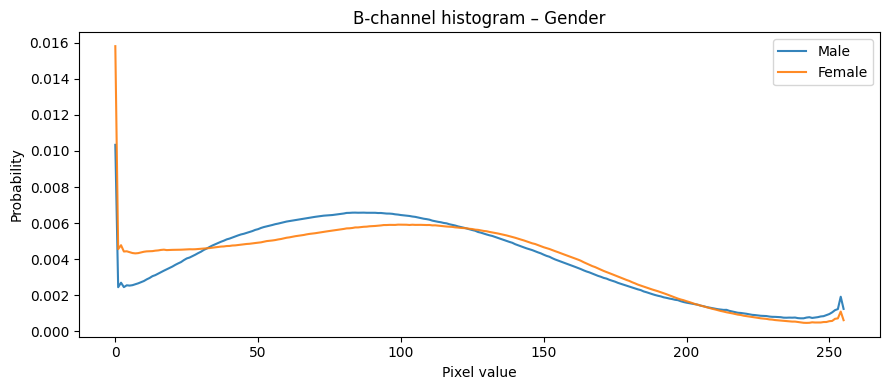

In [18]:
plot_channel_overlay(gender_rgb, "B", "Gender")

Las mujeres muestran un pico en 0 que alcanza 0.016, casi el doble que el pico masculino de 0.010. Esta disparidad refuerza la hipótesis del cabello oscuro ocupando mayor área en las fotografías femeninas. Sin embargo, más allá del pico inicial, las curvas convergen notablemente, siguiendo trayectorias casi idénticas a través del rango medio (50-150) donde ambas alcanzan un máximo amplio alrededor de 100-120. Esta convergencia indica que, una vez excluidas las áreas muy oscuras, las tonalidades azules en rostros masculinos y femeninos son similares. Después del valor 150, ambas curvas decaen de manera prácticamente paralela hacia valores cercanos a cero en el extremo superior, con apenas una ligera ventaja de la curva masculina. Esta similitud en el canal azul contrasta con las diferencias más marcadas en el rojo, sugiriendo que las variaciones de género en el dataset se manifiestan principalmente en los tonos cálidos (rojos) más que en los fríos (azules).


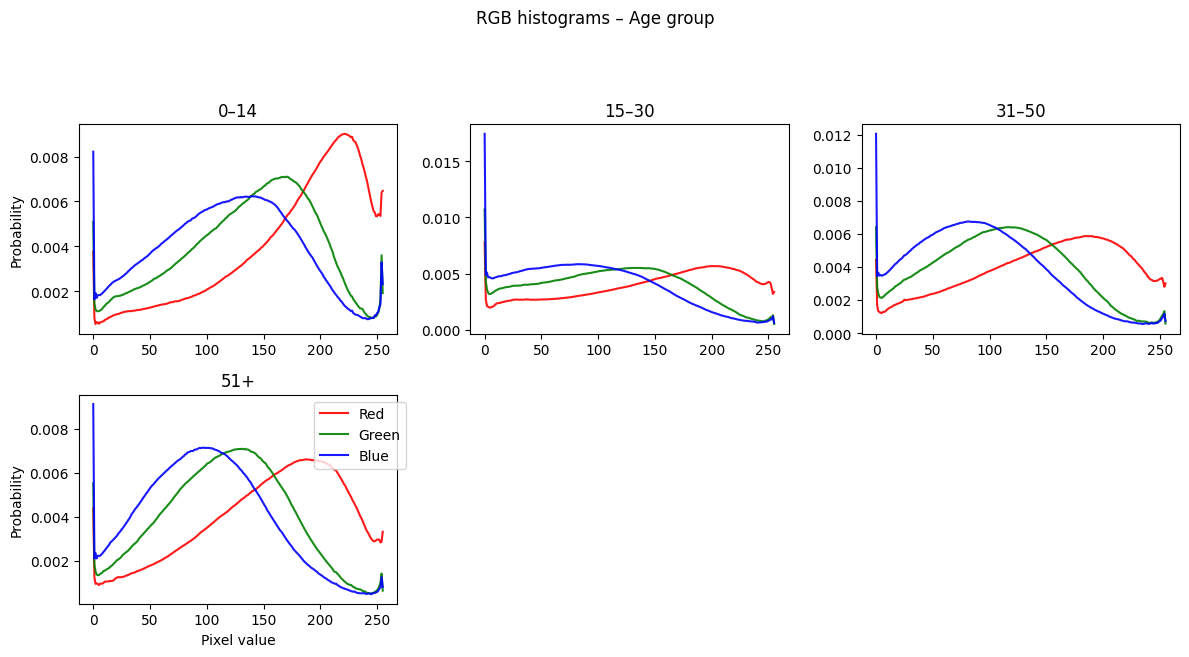

In [19]:
plot_rgb_by_group(age_rgb,"Age group")

El grupo más joven (0-14 años) presenta un patrón distinto a los demás, con un pico inicial modesto (alrededor de 0.008) comparado con otros grupos. Lo más notable es que este grupo muestra un pico rojo extremadamente pronunciado y desplazado hacia valores muy altos (alrededor de 220-230), alcanzando una probabilidad de aproximadamente 0.009, lo cual es inusualmente elevado. Este patrón sugiere que la piel infantil refleja significativamente más luz roja, probablemente debido a que es más delgada, más translúcida y tiene mayor vascularización superficial visible. Los canales verde y azul también muestran distribuciones más anchas y desplazadas hacia valores altos en comparación con otros grupos etarios, pero el rojo domina claramente. Esta característica podría reflejar tanto propiedades biológicas reales de la piel infantil como posibles diferencias en las condiciones de captura fotográfica para este grupo demográfico.

El grupo de 15-30 años presenta el patrón más aplanado y uniforme de todos los grupos de edad. El pico inicial en 0 alcanza aproximadamente 0.018, el más alto de todos los grupos, indicando una presencia masiva de píxeles muy oscuros. Sin embargo, después de este pico, las tres curvas de color se aplanan considerablemente, manteniéndose en valores de probabilidad muy bajos (entre 0.003 y 0.006) a lo largo de todo el rango medio y alto. No hay picos pronunciados en ningún canal, y las curvas son notablemente más planas que las de cualquier otro grupo. Esta distribución uniforme y la dominancia del pico oscuro sugieren que este grupo tiene características fotográficas muy particulares, posiblemente relacionadas con estilos de cabello más oscuro y largo, mayor contraste en la iluminación, o simplemente una mayor variabilidad en las condiciones de captura que produce un promediado de las distribuciones. La ausencia de picos definidos en los rangos medios-altos indica menos consistencia en los tonos de piel comparado con otros grupos.

Los grupos de 31-50 años y 51+ años muestran patrones muy similares entre sí, lo que sugiere una estabilización de las características de color en la edad adulta madura y avanzada. Ambos grupos tienen picos iniciales moderados en 0 (alrededor de 0.012-0.013) y luego presentan distribuciones bien definidas en los rangos medios. El canal azul alcanza un pico alrededor de 100-120, el verde alrededor de 120-150, y el rojo forma un pico más amplio en el rango 150-200. Sin embargo, hay diferencias sutiles pero importantes: el grupo 51+ muestra un pico rojo ligeramente más bajo y más ancho que el grupo 31-50, y sus curvas en general son un poco más aplanadas. Esto podría reflejar cambios en la piel asociados con el envejecimiento, como mayor opacidad, menor reflectancia, o cambios en la pigmentación. La similitud general entre estos dos grupos sugiere que las propiedades ópticas de la piel se mantienen relativamente estables después de los 30 años, con cambios graduales más que transformaciones drásticas.



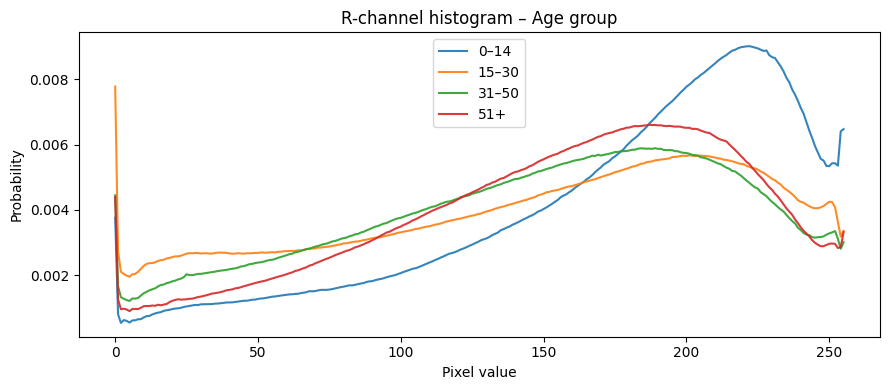

In [20]:
plot_channel_overlay(age_rgb, "R", "Age group")


La curva del grupo 0-14 (azul) es distintiva, mostrando una trayectoria ascendente pronunciada que culmina en un pico dramático alrededor de 220, muy por encima de todos los demás grupos. Esta curva tiene una forma casi gaussiana desplazada hacia valores altos, indicando una distribución concentrada de rojos intensos. En contraste, el grupo 15-30 (naranja) muestra la meseta más plana, con valores que apenas alcanzan 0.004 en el rango medio-alto, y sin ningún pico pronunciado. Los grupos 31-50 (verde) y 51+ (rojo) muestran curvas más similares entre sí, con picos amplios alrededor de 180-200, aunque el grupo 51+ tiene un pico ligeramente más bajo y más extendido. La separación clara entre estas cuatro curvas demuestra que el canal rojo es altamente discriminativo para la edad, con los niños mostrando los valores más altos, los adultos jóvenes los más dispersos, y los adultos maduros y mayores convergiendo hacia patrones intermedios.



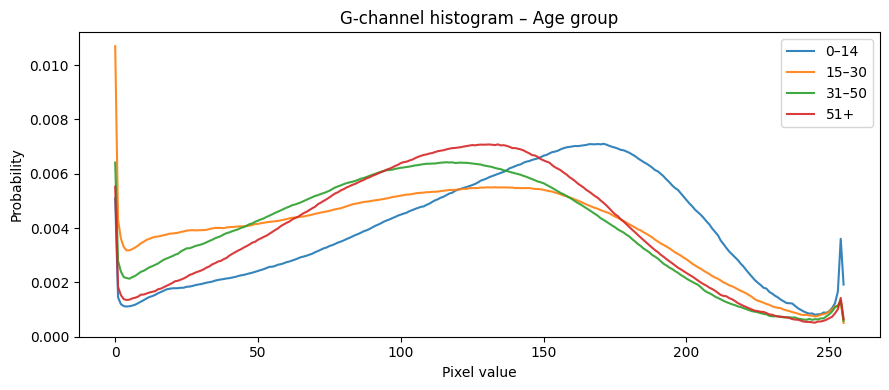

In [21]:
plot_channel_overlay(age_rgb, "G", "Age group")


Nuevamente, el grupo 0-14 se destaca con un pico muy pronunciado alrededor de 150-180, alcanzando una probabilidad de aproximadamente 0.007, significativamente más alto que los otros grupos en esa región. El grupo 15-30 mantiene su característica meseta plana con valores apenas superiores a 0.005 en todo el rango. Los grupos 31-50 y 51+ tienen curvas muy similares con picos alrededor de 120-150, aunque después del valor 150 divergen ligeramente, con el grupo 0-14 manteniendo valores más altos por más tiempo. Una característica interesante es que todas las curvas convergen después del valor 200, sugiriendo que los valores verdes muy altos son igualmente raros en todos los grupos de edad. El pico inicial en 0 muestra una jerarquía clara: 15-30 tiene el pico más alto, seguido por 51+, luego 31-50, y finalmente 0-14 con el más bajo, reforzando la idea de que los adultos jóvenes tienen más píxeles oscuros en sus fotografías.

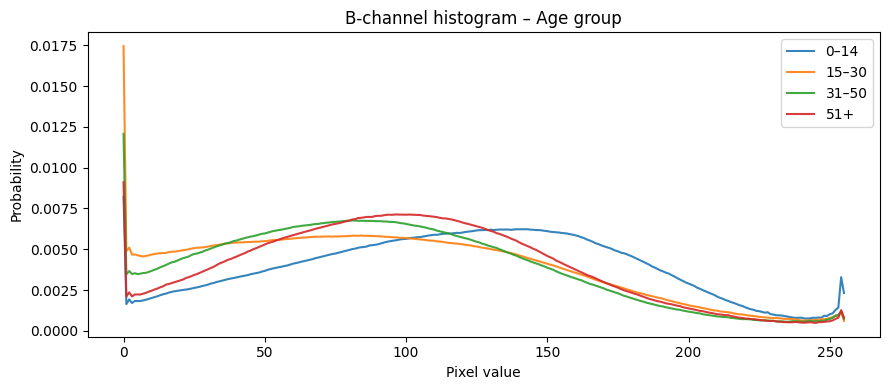

In [22]:
plot_channel_overlay(age_rgb, "B", "Age group")


El canal azul presenta el patrón más uniforme entre grupos de edad, aunque con diferencias notables. Todos los grupos muestran el característico pico inicial en 0, con el grupo 15-30 alcanzando un valor excepcional de aproximadamente 0.018, casi el doble del siguiente grupo más alto. Después del pico inicial, las curvas se separan de manera ordenada: el grupo 0-14 mantiene consistentemente los valores más altos a lo largo del rango 50-200, formando una meseta amplia alrededor de 0.006. Los grupos 31-50 y 51+ tienen curvas casi superpuestas en el rango medio, ambas alcanzando picos de aproximadamente 0.007 alrededor del valor 100. El grupo 15-30 muestra valores intermedios pero sin picos pronunciados. Todas las curvas convergen gradualmente hacia valores bajos después de 150, y prácticamente se superponen después de 200. Esta convergencia en valores altos sugiere que los tonos azules muy intensos son igualmente poco comunes en todos los grupos etarios, y que las diferencias de edad se manifiestan principalmente en los rangos medio-bajos del espectro azul.


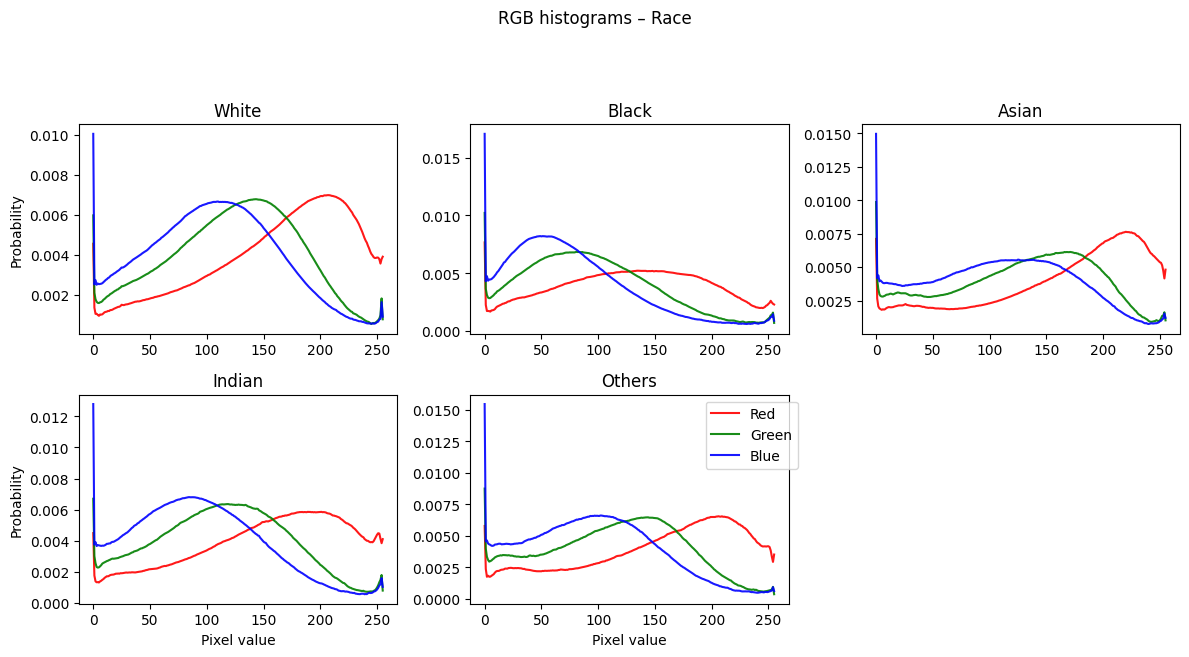

In [23]:
plot_rgb_by_group(race_rgb,   "Race")

La primera gráfica con los cinco paneles separados por grupo racial refleja las variaciones en pigmentación de la piel características de cada grupo. El panel correspondiente a individuos blancos muestra un patrón donde el pico inicial en 0 es relativamente moderado (alrededor de 0.010), seguido por distribuciones amplias en los rangos medios y altos. El canal azul alcanza su pico alrededor de 100-120, el verde alrededor de 120-150, y el rojo forma un pico pronunciado en el rango 180-220, alcanzando una probabilidad cercana a 0.007. Esta jerarquía clara (rojo dominante en valores altos, seguido por verde y azul en valores más bajos) es la firma espectral característica de piel con menor contenido de melanina, donde la reflexión de luz roja es más intensa. El hecho de que el rojo se extienda hacia valores muy altos indica que la piel blanca refleja significativamente más luz en el espectro rojo, consistente con las propiedades ópticas conocidas de piel con baja pigmentación.

El panel correspondiente a individuos negros presenta un contraste dramático con el grupo blanco. El pico inicial en 0 es moderado (alrededor de 0.017), pero lo más distintivo es la ausencia casi total de picos pronunciados en los rangos medios y altos. Las tres curvas de color muestran distribuciones extremadamente aplanadas después del pico inicial, con el verde formando un pico amplio y bajo alrededor de 50-100 (alcanzando apenas 0.007), y el rojo mostrando una meseta extendida en el rango 100-180 con valores máximos de solo 0.005. El canal azul decae rápidamente después del valor 50 y permanece muy bajo en todo el rango alto. Esta distribución refeja directamente el efecto de la alta concentración de melanina en la piel negra, que absorbe gran cantidad de luz en todos los espectros, resultando en valores de píxel generalmente más bajos. La ausencia de un pico rojo en valores altos (como se observa en el grupo blanco) es particularmente notable y representa la diferencia más significativa entre ambos grupos raciales.

El correspondiente a individuos asiáticos muestra características únicas que lo posicionan en un punto intermedio entre los grupos blanco y negro, pero con particularidades propias. El pico inicial en 0 es excepcionalmente alto (aproximadamente 0.015), el más pronunciado de todos los grupos raciales, sugiriendo una presencia masiva de cabello negro que es culturalmente predominante en poblaciones asiáticas. Después de este pico dramático, las curvas se aplanan considerablemente en los rangos bajos y medios, manteniéndose relativamente planas hasta aproximadamente el valor 100. A partir de ahí, el canal rojo comienza a elevarse gradualmente, formando un pico amplio alrededor de 180-200 con una probabilidad de aproximadamente 0.0075, que curiosamente es ligeramente más alta que el pico rojo del grupo blanco. Los canales verde y azul muestran picos más modestos alrededor de 120-140 y 100-120 respectivamente. Este patrón sugiere que la piel asiática, aunque tiene tonos generalmente más cálidos (rojizos) en las áreas iluminadas, también presenta una fuerte componente de píxeles oscuros, creando una distribución bimodal distintiva.

En el panel correspondiente a individuos indios se observa que el pico inicial en 0 es moderado (alrededor de 0.012), menor que el asiático pero comparable al blanco. Las curvas de los tres canales se elevan gradualmente desde valores bajos, con el azul alcanzando su pico primero alrededor de 100-120 (probabilidad de 0.007), seguido por el verde alrededor de 120-150 (también cerca de 0.007), y finalmente el rojo formando un pico más bajo y ancho alrededor de 180-220 con probabilidad de aproximadamente 0.006. Esta distribución refleja la diversidad de tonos de piel dentro del subcontinente indio, que incluye desde pieles relativamente claras hasta muy oscuras. La forma más suave y extendida de las curvas comparada con el grupo blanco sugiere mayor heterogeneidad en la pigmentación, mientras que el pico rojo menos pronunciado que el asiático indica tonos de piel generalmente más cálidos pero menos concentrados en el rango alto.

El panel "Others" (que incluye hispanos, latinos, medio orientales y otros grupos) muestra el patrón más heterogéneo y disperso de todos, lo cual es esperado dada la diversidad inherente a esta categoría. El pico inicial en 0 es moderado-alto (alrededor de 0.015), y las curvas subsecuentes muestran distribuciones amplias sin picos muy pronunciados. El canal azul alcanza su máximo alrededor de 100 con probabilidad de aproximadamente 0.007, el verde forma un pico amplio alrededor de 120-150 alcanzando también cerca de 0.006-0.007, y el rojo muestra una distribución extendida con un pico amplio alrededor de 150-200, alcanzando aproximadamente 0.006. Las curvas son notablemente más aplanadas y extendidas que las de los grupos blancos o asiáticos, sugiriendo que esta categoría abarca un espectro muy amplio de tonos de piel. La ausencia de picos muy definidos y la distribución más uniforme a lo largo del rango completo reflejan la mezcla de características de múltiples grupos étnicos dentro de esta categoría.


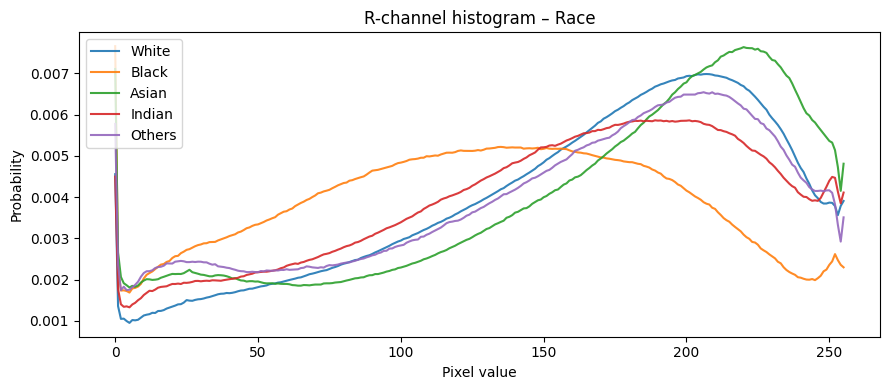

In [24]:
plot_channel_overlay(race_rgb, "R", "Race")


En  el histograma superpuesto del canal rojo observamos que la curva asiática (verde) domina claramente en los valores altos, alcanzando un pico de aproximadamente 0.0075 alrededor del valor 220, la probabilidad más alta de cualquier grupo en ese rango. Las curvas blanca (azul) e india (roja) forman un grupo intermedio, ambas con picos alrededor de 200-220 con probabilidades de 0.006-0.0065, aunque la curva blanca tiene una forma ligeramente más pronunciada. La curva negra (naranja) es absolutamente distintiva, mostrando una meseta aplanada que apenas alcanza 0.005 en el rango 100-150 y decae gradualmente sin formar ningún pico en valores altos. La curva "Others" (púrpura) se posiciona entre la negra y las demás, con valores intermedios a lo largo de todo el rango. Lo más revelador es la separación espacial de las curvas en el rango 150-250: hay una jerarquía clara de arriba hacia abajo (asiática, blanca, india, "Others", negra) que refleja directamente las diferencias en reflexión de luz roja de la piel, que a su vez correlaciona inversamente con el contenido de melanina.

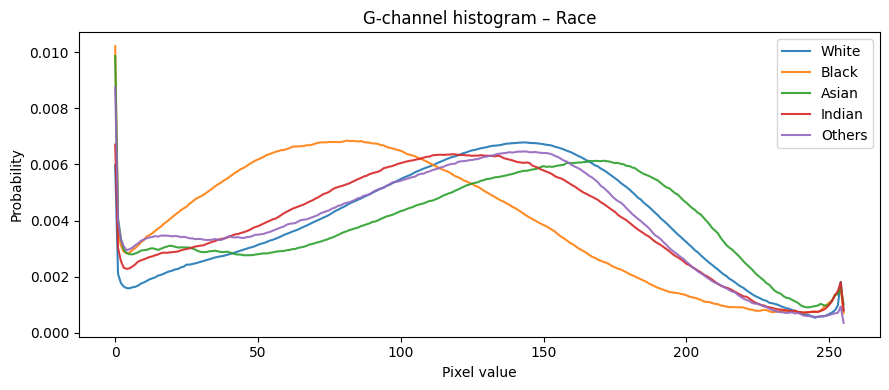

In [25]:
plot_channel_overlay(race_rgb, "G", "Race")


En el histograma superpuesto del canal verde vemos que, la curva negra (naranja) se distingue claramente con un pico temprano y pronunciado alrededor del valor 80-100, alcanzando aproximadamente 0.0065, significativamente más bajo en posición que los otros grupos y decayendo rápidamente después. Las curvas india (roja) y "Others" (púrpura) forman picos amplios alrededor de 140-160, ambas alcanzando probabilidades de 0.006-0.0065. Las curvas blanca (azul) y asiática (verde) tienen picos ligeramente desplazados hacia valores más altos, alrededor de 150-180, con la blanca alcanzando aproximadamente 0.0065 y la asiática llegando a cerca de 0.006. Una característica notable es que, a diferencia del canal rojo donde las diferencias persisten hasta valores muy altos, en el canal verde todas las curvas convergen después del valor 200, indicando que los tonos verdes muy intensos son igualmente raros en todos los grupos raciales. Esta convergencia sugiere que las diferencias raciales se manifiestan principalmente en los rangos bajo y medio del verde, no en los extremos.

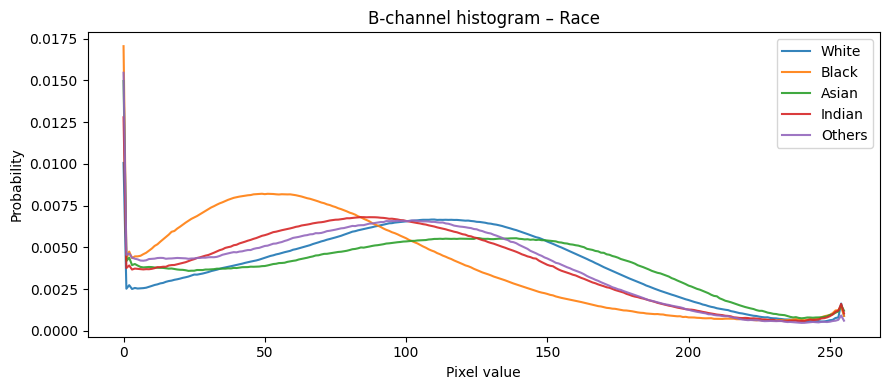

In [26]:
plot_channel_overlay(race_rgb, "B", "Race")

En el histograma vemos que la curva negra (naranja) domina completamente en el rango bajo-medio, formando un pico prominente alrededor del valor 70-80 con una probabilidad excepcional de aproximadamente 0.008, la más alta de cualquier grupo en cualquier posición del canal azul. Este pico temprano y luego el decaimiento rápido reflejan que la piel negra, aunque absorbe más luz en general, todavía refleja proporciones significativas de azul en el rango bajo debido a que la melanina absorbe menos en longitudes de onda más cortas. Las curvas de los otros cuatro grupos muestran picos más tardíos y más bajos: india (roja) alcanza su máximo alrededor de 100-110 con probabilidad de 0.007, seguida por blanca (azul), asiática (verde) y "Others" (púrpura), todas alcanzando picos alrededor de 110-120 con probabilidades de 0.006-0.0065. Todas las curvas excepto la negra se superponen considerablemente en el rango medio-alto, sugiriendo que el canal azul es particularmente efectivo para distinguir piel negra de otros grupos, pero menos útil para discriminar entre grupos con pigmentación baja a media.

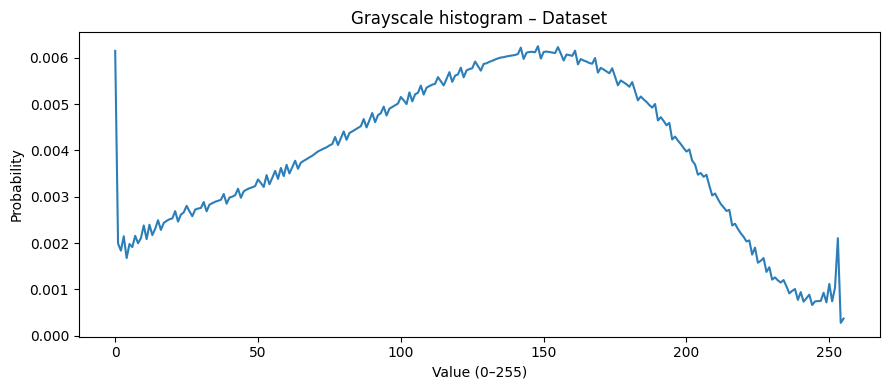

In [27]:
plot_scalar_dataset(
    Gray_plot, "Grayscale histogram – Dataset",
    "Probability" if NORMALIZE else "Count", "gray_dataset"
)

El histograma de escala de grises del dataset completo ofrece una visión integrada de la luminosidad general de todas las imágenes, consolidando la información de los tres canales RGB en una sola dimensión que representa el brillo percibido. La distribución muestra un pico pronunciado en el valor 0 con una probabilidad de aproximadamente 0.006, seguido por un descenso rápido hasta un mínimo local alrededor del valor 10-15. A partir de ahí, la curva asciende de manera casi lineal y sostenida desde el valor 20 hasta aproximadamente el valor 150, donde alcanza una meseta amplia con pequeñas oscilaciones que mantienen probabilidades entre 0.006 y 0.0065. Este rango extendido de valores altos con probabilidades sostenidas representa la luminosidad característica de la piel facial bajo diversas condiciones de iluminación. Después del valor 150, la distribución decae gradualmente hasta el valor 220, donde cae abruptamente hacia valores cercanos a cero, con un pequeño pico residual cerca del valor 255. Esta forma general sugiere que el dataset tiene una buena representación de tonos medios y medio-altos, consistente con fotografías faciales bien expuestas donde la piel ocupa porciones significativas del encuadre.

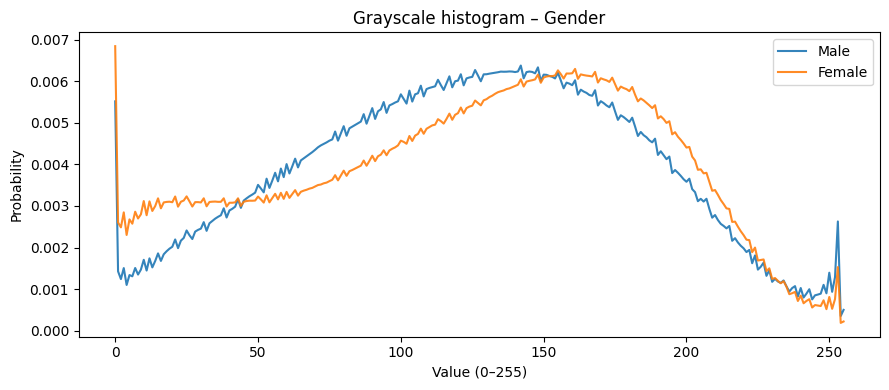

In [28]:
# Grayscales by gender / age group / race
plot_scalar_by_group(gender_gray, "Grayscale histogram – Gender",
                     "Probability" if NORMALIZE else "Count", "gray_by_gender")


El histograma de escala de grises por género revela diferencias sistemáticas en la distribución de luminosidad entre hombres y mujeres que complementan y confirman los patrones observados en los canales RGB individuales. La curva masculina (azul) muestra un pico inicial en 0 de aproximadamente 0.006, notablemente más bajo que el pico femenino que alcanza cerca de 0.007. Después de este pico inicial, la curva masculina asciende más rápidamente que la femenina, alcanzándola alrededor del valor 60 y superándola consistentemente en todo el rango medio y medio-alto. El pico masculino se sitúa alrededor de los valores 140-160 con probabilidad de aproximadamente 0.0065, mientras que el pico femenino es ligeramente más bajo y más desplazado hacia valores menores, alcanzando aproximadamente 0.006 alrededor de los valores 130-150. Esta diferencia sugiere que los rostros masculinos en el dataset tienden a tener mayor luminosidad promedio, lo cual es consistente con la observación previa de que los hombres mostraban distribuciones RGB más desplazadas hacia valores altos. Después del valor 180, ambas curvas convergen y decaen de manera similar, aunque la masculina mantiene una ligera ventaja hasta el final. El contraste entre el pico inicial más alto en mujeres pero valores sostenidos más altos en hombres para el rango medio-alto refuerza la interpretación de que las fotografías femeninas contienen proporcionalmente más píxeles muy oscuros (probablemente cabello), pero que las áreas faciales masculinas reflejan más luz en promedio.

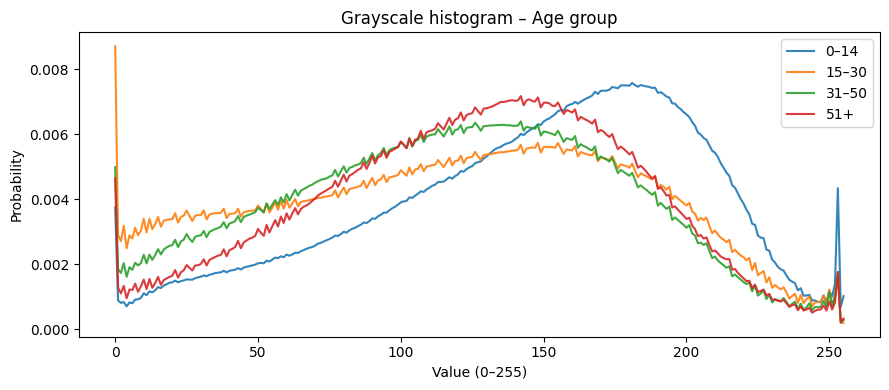

In [29]:
plot_scalar_by_group(age_gray,    "Grayscale histogram – Age group",
                     "Probability" if NORMALIZE else "Count", "gray_by_age")


El grupo 0-14 años (azul) presenta el patrón más distintivo de todos, con un pico inicial en 0 moderado (alrededor de 0.005) seguido por un ascenso constante y sostenido que continúa hasta alcanzar su máximo alrededor del valor 200, donde forma una meseta amplia con probabilidad de aproximadamente 0.0075. Este desplazamiento dramático hacia valores muy altos es consistente con la observación previa de que la piel infantil refleja mucha más luz, especialmente en el canal rojo. El grupo 15-30 años (naranja) muestra el pico inicial más alto de todos los grupos (cerca de 0.009), reflejando la presencia masiva de píxeles oscuros, pero luego mantiene una meseta relativamente plana en el rango 30-150 con probabilidades entre 0.0045 y 0.006, significativamente más bajas que los otros grupos en esos rangos. Los grupos 31-50 (verde) y 51+ (rojo) muestran curvas muy similares entre sí, con picos iniciales moderados alrededor de 0.006-0.007 y mesetas amplias en el rango 120-160 con probabilidades de aproximadamente 0.0065-0.007. La separación clara entre estas cuatro curvas, especialmente en el rango 100-200, demuestra que la edad produce cambios sistemáticos en la luminosidad facial que son fácilmente detectables en escala de grises. La transición gradual desde las distribuciones desplazadas hacia valores altos en niños hasta las distribuciones más centradas en adultos refleja los cambios en las propiedades ópticas de la piel con el envejecimiento.

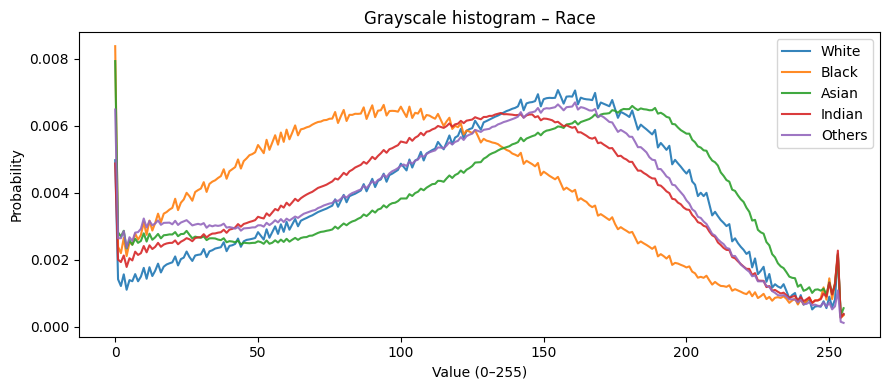

In [30]:
plot_scalar_by_group(race_gray,   "Grayscale histogram – Race",
                     "Probability" if NORMALIZE else "Count", "gray_by_race")

La curva negra (naranja) se distingue inmediatamente y dramáticamente de todas las demás, mostrando un pico temprano y pronunciado alrededor del valor 100-120 con probabilidad de aproximadamente 0.0065, seguido por un decaimiento rápido que lleva a valores muy bajos después del valor 180. Esta distribución fuertemente desplazada hacia valores bajos refleja directamente el efecto de la alta concentración de melanina en absorber luz a través de todo el espectro visible, resultando en valores de luminosidad consistentemente más bajos. Las curvas blanca (azul), asiática (verde), india (roja) y "Others" (púrpura) forman un grupo más cohesionado pero con separaciones significativas. La curva blanca muestra valores relativamente bajos en el rango 20-100, pero luego asciende constantemente hasta formar un pico amplio alrededor de 160-180 con probabilidad de 0.0065-0.007. La curva asiática es particularmente interesante: después del pico inicial excepcional en 0 (alrededor de 0.0085, el más alto de todos los grupos), se mantiene relativamente baja en el rango 20-100, pero luego asciende para formar un pico alrededor de 180-200, alcanzando aproximadamente 0.0065, ligeramente superior al pico blanco. La curva india muestra un comportamiento intermedio, con un ascenso gradual que culmina en una meseta alrededor de 140-160 con probabilidad de 0.006-0.0065. La curva "Others" presenta la mayor variabilidad, con valores intermedios a lo largo de todo el rango.

La separación espacial de las curvas en el rango medio-alto (100-180) es particularmente reveladora sobre las diferencias raciales en luminosidad. En este rango crítico donde se concentra la mayor parte de la información facial, las curvas se ordenan de manera consistente: la curva negra permanece en la parte inferior con valores que apenas alcanzan 0.006 alrededor del valor 100 y luego decaen rápidamente; la curva "Others" ocupa una posición intermedia-baja; las curvas india y blanca se entrelazan en posiciones intermedias-altas; y la curva asiática, sorprendentemente, alcanza y en algunos puntos supera a todas las demás en el rango 160-200. Este patrón complejo sugiere que la luminosidad de la piel no sigue una jerarquía racial simple, sino que refleja interacciones complejas entre pigmentación, condiciones de captura fotográfica, y posiblemente diferencias en el estilo de presentación o maquillaje entre grupos culturales. La convergencia de todas las curvas después del valor 220 indica que los valores de luminosidad extremadamente altos son igualmente raros en todos los grupos raciales, sugiriendo que las diferencias se concentran en los rangos medios donde reside la mayor parte de la información sobre el tono de piel.

Comparando los cuatro histogramas de escala de grises en conjunto, emerge un patrón coherente donde el género produce diferencias relativamente modestas, la edad produce diferencias dramáticas especialmente para el grupo infantil, y la raza produce las separaciones más pronunciadas y sistemáticas en el rango medio de luminosidad. El pico inicial en 0 es una característica universal pero con magnitudes variables que reflejan diferencias en la cantidad de cabello oscuro visible, siendo más pronunciado en mujeres, adultos jóvenes, y poblaciones asiáticas. Las mesetas extendidas en rangos medios-altos son características de grupos con piel más clara y fotografías bien iluminadas, mientras que las distribuciones desplazadas hacia valores bajos son características de piel con mayor pigmentación. La representación en escala de grises simplifica la visualización de estas diferencias demográficas, pero también oculta información importante sobre el balance cromático que solo es visible en los canales RGB individuales. En conjunto, estos histogramas demuestran que el dataset UTKFace codifica diferencias demográficas no solo en características faciales geométricas sino también profundamente en las distribuciones de color y luminosidad, lo cual tiene implicaciones importantes para el diseño de algoritmos de visión por computadora que deben ser justos y equitativos a través de diferentes grupos demográficos.

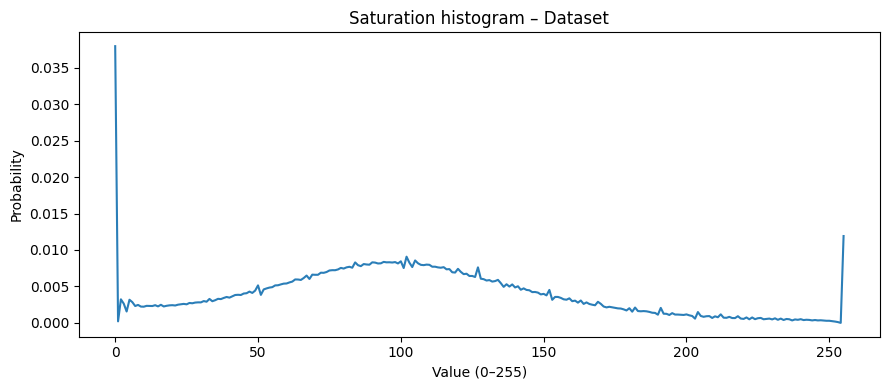

In [31]:
plot_scalar_dataset(
    S_plot, "Saturation histogram – Dataset",
    "Probability" if NORMALIZE else "Count", "saturation_dataset"
)

La característica más dominante es un pico masivo en el valor 0 con una probabilidad de aproximadamente 0.038, casi cuatro veces mayor que cualquier otro valor en toda la distribución. Este pico extraordinario indica que cerca del 4% de todos los píxeles en el dataset son completamente acromáticos, es decir, tienen saturación cero y corresponden a tonos de gris puro, negro o blanco. Esta concentración masiva en saturación cero puede atribuirse a múltiples factores: píxeles completamente negros del fondo o cabello oscuro, áreas de sombra profunda donde el color se pierde, y posiblemente regiones sobreexpuestas donde la saturación también tiende a cero. Después de este pico dramático, la distribución cae abruptamente a valores muy bajos alrededor de 0.002-0.003 en el rango 5-20, formando un valle pronunciado. A partir del valor 30, la curva comienza a ascender gradualmente, alcanzando un máximo amplio y relativamente plano en el rango 90-110 con probabilidades entre 0.008 y 0.009. Esta meseta extendida representa los tonos de piel con saturación moderada, característica de la coloración facial natural. Después del valor 120, la distribución decae monotónicamente hasta valores cercanos a cero alrededor del valor 220, seguido por un pequeño pico residual en 255 con probabilidad de aproximadamente 0.012, que representa píxeles completamente saturados.

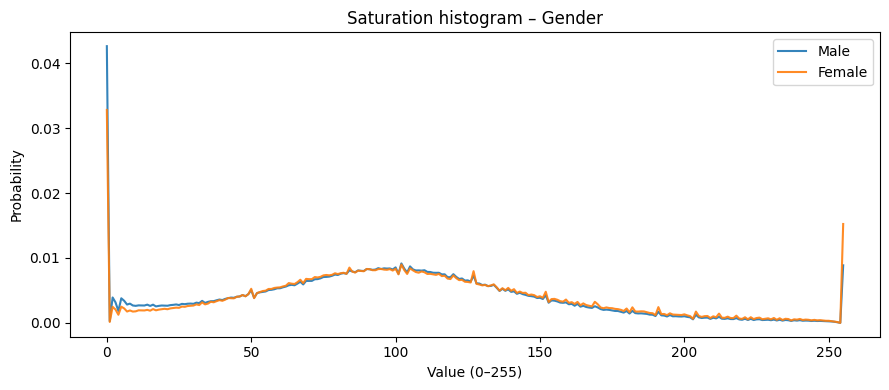

In [32]:
plot_scalar_by_group(gender_s, "Saturation histogram – Gender","Probability" if NORMALIZE else "Count", "saturation_by_gender")

Ambas curvas exhiben el pico dramático en 0, pero con magnitudes notablemente diferentes, la curva femenina (naranja) alcanza aproximadamente 0.045, mientras que la masculina (azul) llega solo a cerca de 0.043. Esta diferencia refuerza la observación consistente de que las fotografías femeninas contienen proporcionalmente más píxeles acromáticos, probablemente debido al cabello oscuro ocupando mayor área del encuadre. Después del valle inicial, ambas curvas ascienden gradualmente, pero la curva femenina se mantiene consistentemente por encima de la masculina en todo el rango medio (30-150), alcanzando un pico máximo alrededor de 100-110 con probabilidad de aproximadamente 0.009, comparado con 0.008 para los hombres. Esta diferencia sugiere que los rostros femeninos en el dataset tienen, en promedio, mayor saturación cromática en los rangos medios, lo cual podría atribuirse al uso de maquillaje que típicamente aumenta la saturación de colores faciales, o posiblemente a diferencias en el procesamiento fotográfico. Después del valor 150, ambas curvas convergen y decaen de manera casi idéntica, indicando que los valores de alta saturación son igualmente raros en ambos géneros. El pico terminal en 255 es notable en ambas curvas, siendo ligeramente más pronunciado en la femenina (aproximadamente 0.016 vs 0.012), sugiriendo presencia de píxeles artificialmente saturados o artefactos de compresión JPEG que afectan ligeramente más a las imágenes femeninas.

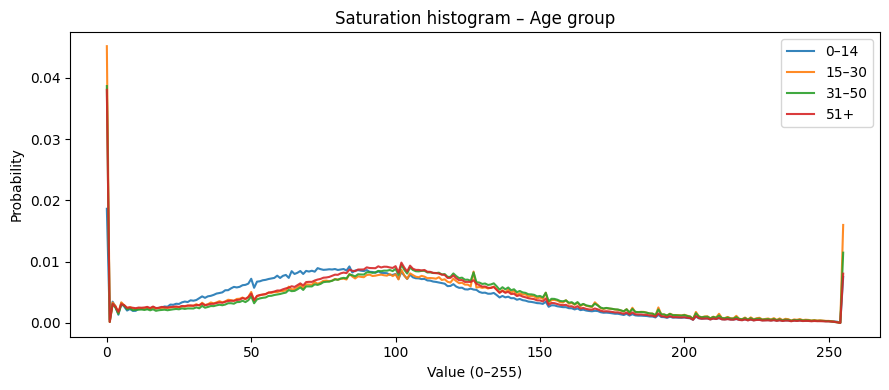

In [33]:
plot_scalar_by_group(age_s,    "Saturation histogram – Age group","Probability" if NORMALIZE else "Count", "saturation_by_age")

Todos los grupos muestran el pico masivo en 0, pero con una jerarquía clara: el grupo 15-30 tiene el pico más alto (aproximadamente 0.048), seguido por 51+ (cerca de 0.042), luego 31-50 (alrededor de 0.040), y finalmente 0-14 con el pico más bajo (aproximadamente 0.038). Esta ordenación es consistente con las observaciones previas sobre la presencia de píxeles oscuros, sugiriendo que los adultos jóvenes tienen la mayor proporción de áreas acromáticas. Sin embargo, después del valle inicial, las curvas muestran un comportamiento sorprendentemente convergente: los cuatro grupos forman una meseta amplia en el rango 80-130 con probabilidades muy similares, todas entre 0.008 y 0.010, con el grupo 0-14 mostrando valores apenas superiores a los demás. Esta convergencia notable indica que, una vez excluidos los píxeles completamente desaturados, la saturación cromática de la piel facial es notablemente consistente a través de diferentes edades. La similitud de las curvas en el rango medio contradice la expectativa de que la piel infantil, siendo más translúcida y vascularizada, tendría mayor saturación; en realidad, las diferencias son mínimas. Después del valor 150, todas las curvas decaen de manera prácticamente idéntica, y el pico terminal en 255 es comparable en todos los grupos, con valores alrededor de 0.010-0.016. Esta uniformidad en saturación entre grupos de edad es uno de los hallazgos más sorprendentes y sugiere que la saturación cromática es menos útil como característica discriminativa para clasificación de edad que la luminosidad o las distribuciones RGB.

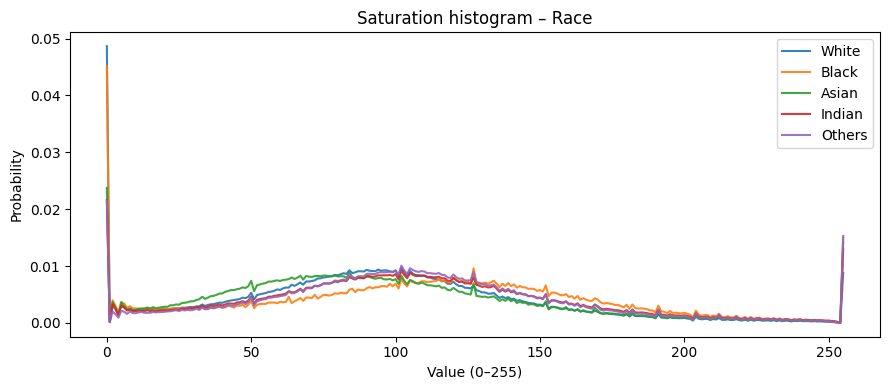

In [34]:
plot_scalar_by_group(race_s,"Saturation histogram – Race","Probability" if NORMALIZE else "Count", "saturation_by_race")

Todos los grupos muestran el pico dominante en 0, pero con una jerarquía interesante: la curva negra (naranja) tiene el pico más alto (aproximadamente 0.048), seguida por asiática (verde, cerca de 0.047), luego blanca (azul, alrededor de 0.045), india (roja, cerca de 0.043), y finalmente "Others" (púrpura, aproximadamente 0.042). Esta ordenación es parcialmente consistente con los patrones de píxeles oscuros observados previamente, aunque con algunas sorpresas, particularmente el pico excepcionalmente alto del grupo negro que no se observó tan claramente en los histogramas de luminosidad. Después del valle inicial, las curvas divergen de manera más pronunciada que en el análisis por edad. En el rango medio (50-130), las curvas se ordenan aproximadamente así de arriba hacia abajo: india alcanzando aproximadamente 0.010, seguida por blanca y "Others" con valores cercanos a 0.009, luego asiática con alrededor de 0.008, y finalmente negra con valores más bajos alrededor de 0.007. Esta jerarquía inversa (comparada con el pico en 0) es reveladora: los grupos con más píxeles completamente desaturados (negro, asiático) tienen menor saturación en los rangos medios, mientras que los grupos con menos píxeles en 0 (indio, "Others") mantienen saturaciones medias más altas. Esto sugiere que las pieles más oscuras no solo absorben más luz sino que también exhiben menor saturación cromática perceptible en los tonos medios.


La región entre los valores 80 y 130, donde se concentra la información sobre saturación de la piel, merece un análisis más detallado. Las curvas india (roja) y "Others" (púrpura) forman un grupo superior en esta región, manteniendo probabilidades alrededor de 0.009-0.010, lo que indica que estos grupos tienen distribuciones de saturación más ricas y variadas en sus tonos de piel. La curva blanca (azul) ocupa una posición intermedia-alta, con valores alrededor de 0.0085-0.009, sugiriendo saturación moderada-alta consistente con piel clara bajo buena iluminación. La curva asiática (verde) se posiciona en un nivel intermedio-bajo con valores alrededor de 0.007-0.008, lo cual es interesante dado que este grupo mostró valores de luminosidad relativamente altos en análisis previos; esto sugiere que la piel asiática en el dataset tiende hacia tonos brillantes pero menos saturados. La curva negra (naranja) permanece consistentemente en la parte inferior en este rango crítico, con probabilidades que apenas alcanzan 0.007, reflejando que la alta concentración de melanina no solo reduce la reflexión de luz sino también la saturación cromática perceptible, resultando en tonos que son más cercanos al gris aunque no completamente acromáticos. Después del valor 150, todas las curvas convergen rápidamente hacia valores muy bajos, y el pico terminal en 255 muestra valores similares en todos los grupos (alrededor de 0.015-0.018), indicando que los píxeles completamente saturados son igualmente raros o igualmente artefactuales en todos los grupos raciales.

Comparando los cuatro histogramas de saturación en conjunto, emergen varios patrones fundamentales sobre la naturaleza cromática del dataset UTKFace. El pico masivo en saturación cero es universal y dominante, representando entre 3.8% y 4.8% de todos los píxeles dependiendo del grupo demográfico, lo cual es una proporción extraordinariamente alta que refleja la presencia ubicua de elementos acromáticos (cabello negro, sombras profundas, fondos) en fotografías faciales. Las diferencias de género en saturación son relativamente modestas pero consistentes, con las mujeres mostrando ligeramente mayor saturación en rangos medios. Las diferencias de edad son sorprendentemente pequeñas en saturación, con todas las edades convergiendo hacia distribuciones similares en el rango crítico de tonos de piel, sugiriendo que la saturación es menos informativa para clasificación de edad que otras características de color. Las diferencias raciales en saturación son las más pronunciadas y sistemáticas, con una jerarquía clara donde grupos con pigmentación más clara muestran mayor saturación en rangos medios, mientras que grupos con mayor pigmentación muestran más píxeles completamente desaturados y menor saturación en rangos medios. El pico terminal en 255 presente en todos los histogramas es probablemente un artefacto de procesamiento de imagen o compresión JPEG más que un fenómeno biológico real. En general, el análisis de saturación complementa los análisis previos de RGB y luminosidad, revelando que las diferencias demográficas en el dataset se manifiestan no solo en cuánta luz refleja la piel sino también en qué tan cromáticamente rica es esa reflexión.

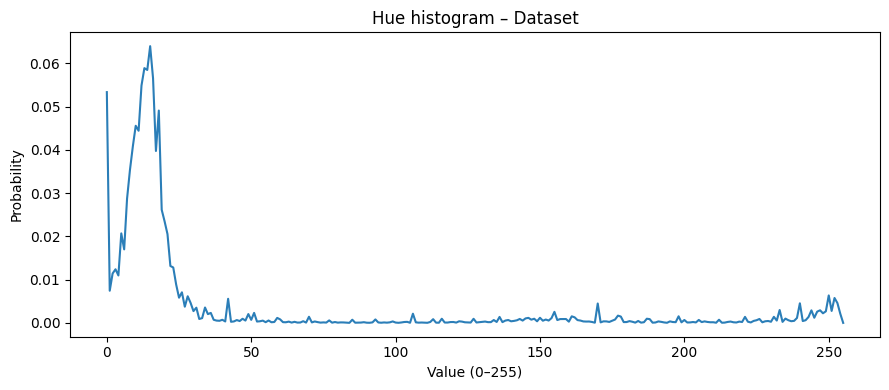

In [35]:
plot_scalar_dataset(H_plot, "Hue histogram – Dataset","Probability" if NORMALIZE else "Count", "hue_dataset")

El histograma de matiz del dataset completo revela la distribución de tonalidades cromáticas presentes en las imágenes. Observamos un pico extremadamente pronunciado y estrecho en el rango de valores muy bajos, específicamente entre 0 y 20, con un máximo absoluto alrededor del valor 10-15 que alcanza una probabilidad excepcional de aproximadamente 0.065. Este pico masivo corresponde a los tonos rojo-naranja del espectro de matiz, que son precisamente los colores característicos de la piel humana. En el espacio HSV, el matiz se representa circularmente con el rojo en 0°, pasando por naranja, amarillo, verde, cian, azul, magenta, y volviendo al rojo en 360° (representado como 255 en la escala de 8 bits). La concentración abrumadora de píxeles en el rango 0-20 indica que la gran mayoría de los píxeles cromáticos en el dataset corresponden a tonos de piel rojo-anaranjados. Después de este pico dominante, la distribución cae precipitadamente a valores muy bajos alrededor de 0.001-0.002 a partir del valor 30, manteniéndose en niveles casi planos y extremadamente bajos a lo largo de todo el rango medio (40-200) con pequeñas oscilaciones que representan colores de fondo, ropa u otros elementos no faciales. Hacia el final del espectro (valores 230-255), hay un leve incremento que representa el retorno al rojo en el círculo cromático, aunque mucho menos pronunciado que el pico inicial.

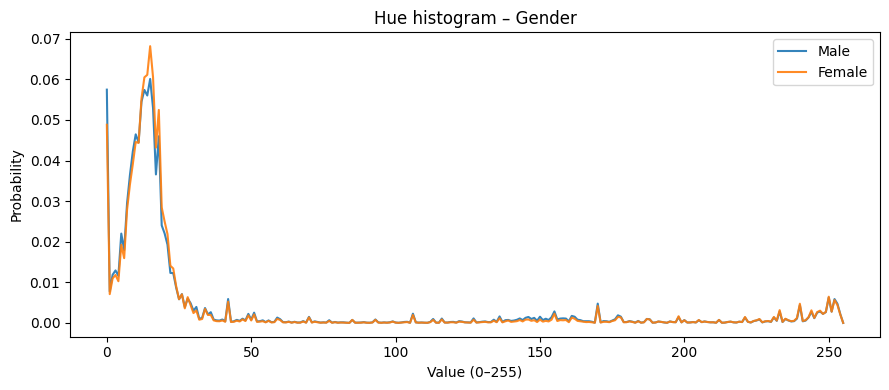

In [36]:
plot_scalar_by_group(gender_h, "Hue histogram – Gender","Probability" if NORMALIZE else "Count", "hue_by_gender")

El histograma de matiz por género muestra una superposición casi perfecta entre las curvas masculina y femenina,ambas curvas exhiben el pico masivo en el rango 0-20, con la curva femenina (naranja) alcanzando un máximo ligeramente superior de aproximadamente 0.068 comparado con 0.062 de la masculina (azul), situado alrededor del valor 12-15. Esta diferencia de aproximadamente 10% en la altura del pico sugiere que las imágenes femeninas tienen una concentración ligeramente mayor de píxeles en los tonos de piel rojo-naranja, lo cual podría atribuirse a diferencias en la composición fotográfica (más área facial visible versus cabello), el uso de maquillaje que enfatiza tonos cálidos, o simplemente diferencias en la distribución de tonos de piel naturales. Después del pico inicial, ambas curvas decaen de manera casi idéntica, manteniéndose superpuestas a lo largo de todo el rango medio con valores extremadamente bajos alrededor de 0.001-0.002. Las pequeñas oscilaciones y picos secundarios que aparecen esporádicamente en el rango 50-250 son prácticamente indistinguibles entre géneros, sugiriendo que los colores de fondo, ropa y otros elementos no faciales tienen distribuciones similares en imágenes de hombres y mujeres. El incremento final cerca del valor 255 también es comparable en ambos grupos. Esta similitud notable en la distribución de matiz entre géneros es uno de los hallazgos más significativos y sugiere que, a nivel de tonalidad cromática fundamental, los rostros masculinos y femeninos en el dataset son esencialmente indistinguibles, con las diferencias de género manifestándose más en luminosidad y saturación que en el matiz puro.

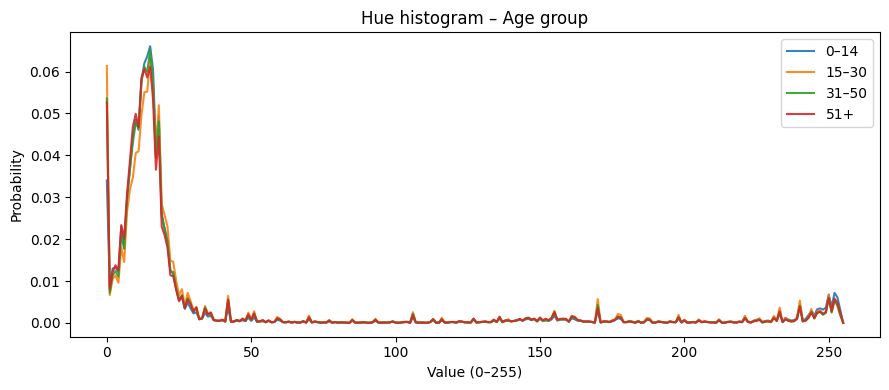

In [37]:
plot_scalar_by_group(age_h,"Hue histogram – Age group","Probability" if NORMALIZE else "Count", "hue_by_age")

El histograma de matiz por grupo de edad muestra una gran alineación entre todos los grupos revelando que la tonalidad fundamental de la piel humana permanece constante a lo largo del ciclo de vida. Los cuatro grupos muestran picos prácticamente superpuestos. Esta superposición casi perfecta después del valor 30 es notable y demuestra que los colores no relacionados con la piel (fondos, ropa, accesorios) tienen distribuciones muy similares en fotografías de personas de diferentes edades. La implicación más importante de este análisis es que el matiz, a diferencia de la luminosidad, es una característica muy poco informativa para la clasificación de edad, ya que la tonalidad fundamental de la piel se mantiene en el rango rojo-naranja independientemente de la edad.

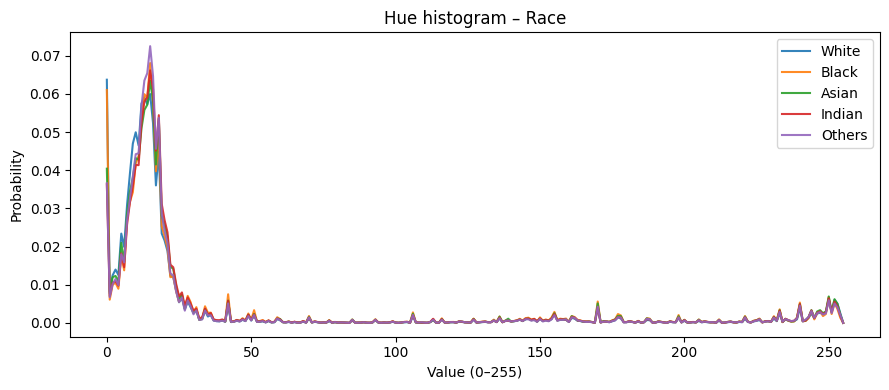

In [38]:
plot_scalar_by_group(race_h,   "Hue histogram – Race","Probability" if NORMALIZE else "Count", "hue_by_race")

 Todas las cinco curvas muestran el pico dramático en el rango 0-20, confirmando que independientemente de la raza, el tono fundamental de la piel humana cae en el espectro rojo-naranja. Sin embargo, hay diferencias cuantitativas notables en las alturas de los picos. La curva asiática (verde) alcanza el pico más alto de aproximadamente 0.074, seguida por "Others" (púrpura) con cerca de 0.070, luego india (roja) con alrededor de 0.067, blanca (azul) con aproximadamente 0.064, y finalmente negra (naranja) con el pico más bajo de cerca de 0.063. Esta jerarquía es particularmente interesante porque invierte parcialmente las jerarquías observadas en luminosidad. El grupo asiático, que mostró valores de luminosidad relativamente altos, también muestra la mayor concentración de píxeles en el matiz de piel, mientras que el grupo negro, que tenía los valores de luminosidad más bajos, tiene aquí el pico de matiz más bajo. Esta aparente paradoja se explica porque el matiz solo cuenta píxeles que tienen saturación suficiente para ser clasificados como cromáticos, mientras que los píxeles muy oscuros o muy claros con baja saturación no contribuyen significativamente al histograma de matiz. Por lo tanto, el pico más bajo del grupo negro refleja que una mayor proporción de sus píxeles son tan oscuros que caen fuera del rango cromático detectable, o tienen saturación tan baja que el matiz se vuelve indefinido.

 Analizando más detalladamente la región del pico (valores 0-30), se observan diferencias sutiles en la forma y posición exacta de los máximos entre grupos raciales. El pico asiático no solo es el más alto sino también el más estrecho y concentrado, sugiriendo menor variabilidad en los tonos de piel dentro de este grupo. El pico del grupo "Others" es comparable en altura pero ligeramente más ancho, reflejando la mayor heterogeneidad esperada en esta categoría mixta. Los picos de los grupos indio y blanco son intermedios tanto en altura como en anchura, sugiriendo variabilidad moderada. El pico del grupo negro, aunque es el más bajo, tiene una base ligeramente más ancha que se extiende más hacia valores de matiz más altos (hacia el amarillo), lo que podría reflejar la presencia de tonos de piel con matices ligeramente diferentes o mayor variabilidad dentro del grupo. Es importante notar que todos los picos están centrados aproximadamente en el mismo valor (10-15), correspondiente a tonos naranja-rojizos, confirmando que esta es la tonalidad universal de la piel humana independientemente de la cantidad de melanina. La diferencia principal entre razas no está en qué matiz tiene la piel, sino en cuántos píxeles tienen suficiente luminosidad y saturación para que ese matiz sea medible.
 
Después del pico inicial, todas las curvas raciales convergen hacia valores extremadamente bajos y prácticamente indistinguibles a lo largo del rango 40-220. Esta región plana con valores alrededor de 0.001-0.002 representa colores no relacionados con la piel que aparecen en fondos, ropa y accesorios. La superposición casi perfecta de las cinco curvas en este rango indica que estos elementos secundarios tienen distribuciones de color similares independientemente de la raza del sujeto fotografiado, sugiriendo condiciones de captura relativamente estandarizadas en el dataset. Hay pequeños picos esporádicos que aparecen en todas las curvas alrededor de los valores 150-170 (correspondientes a cianos y azules) que probablemente representan elementos de fondo o ropa, pero estos son tan pequeños (probabilidades menores a 0.005) que son insignificantes comparados con el pico dominante de tono de piel. Hacia el extremo superior del espectro (valores 230-255), todas las curvas muestran un ligero incremento que representa el retorno al rojo en el círculo cromático, con magnitudes similares entre grupos raciales. Este incremento terminal es mucho menos pronunciado que el pico inicial, indicando que los rojos puros intensos son relativamente raros en el dataset comparados con los naranja-rojizos de la piel.

Comparando los cuatro histogramas de matiz en conjunto, concluimos que el matiz es la característica más universalmente compartida entre todos los grupos demográficos. 

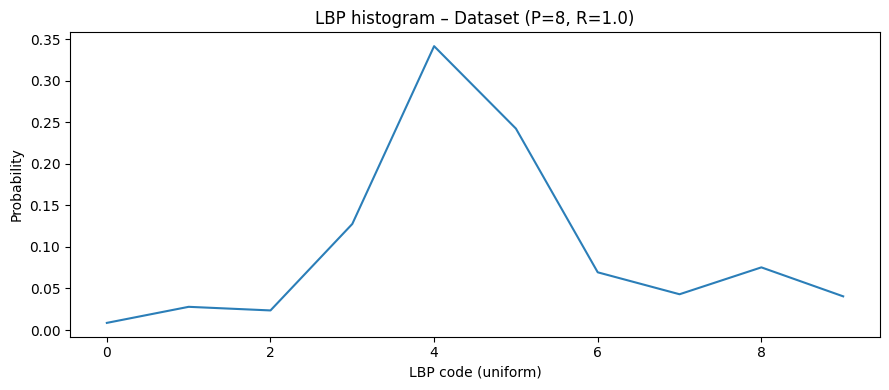

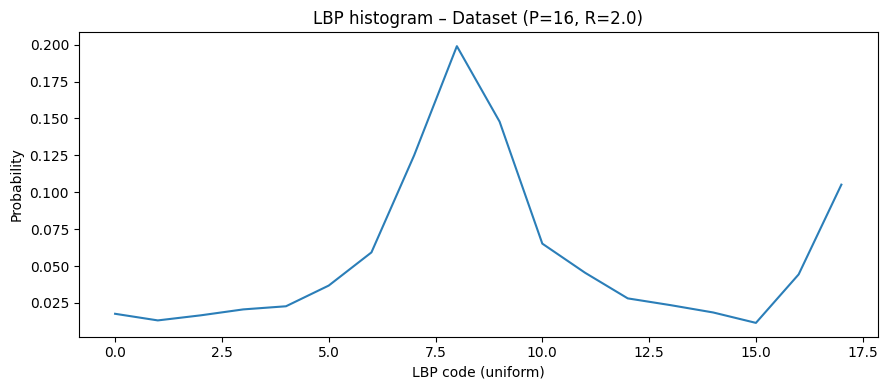

In [39]:
plot_lbp_dataset(LBP_plots_overall, LBP_SETTINGS)

Los histogramas de Local Binary Patterns del dataset completo proporcionan información sobre las características de textura presentes en las imágenes faciales. Se analizan dos configuraciones diferentes de LBP: una con P=8 y R=1.0 (8 puntos de muestreo en un radio de 1 píxel) y otra con P=16 y R=2.0 (16 puntos en radio 2), donde ambas usan el método "uniform" que clasifica patrones en P+2 categorías. El histograma LBP con P=8 muestra una distribución altamente concentrada con un pico dominante en el código 4 que alcanza una probabilidad excepcional de aproximadamente 0.34, lo que significa que más de un tercio de todos los píxeles en el dataset exhiben este patrón de textura específico. Este código particular representa un patrón uniforme donde hay exactamente dos transiciones binarias en el vecindario circular, típicamente asociado con regiones de gradiente suave o bordes suaves, que son característicos de la piel facial bien iluminada. Los códigos 0-3 muestran probabilidades muy bajas (0.01-0.03), representando patrones más simples como áreas planas o con una sola transición. Después del pico masivo en 4, la distribución decae rápidamente: el código 5 tiene probabilidad de aproximadamente 0.07, y los códigos 6-9 mantienen valores entre 0.04 y 0.08. El código 9, que representa patrones no uniformes (aquellos con más de dos transiciones), tiene una probabilidad de aproximadamente 0.04, indicando que las texturas complejas o ruidosas son relativamente poco comunes en el dataset.

El histograma LBP con P=16 y R=2.0 muestra un patrón fundamentalmente similar, el pico dominante ahora está en el código 8, alcanzando una probabilidad de aproximadamente 0.20, significativamente menor que el 0.34 del caso P=8. Esta reducción en la concentración del pico refleja que al muestrear en un radio mayor, se captura mayor variabilidad en las texturas locales, resultando en una distribución más dispersa. Los códigos 0-7 muestran una tendencia ascendente gradual con probabilidades entre 0.02 y 0.06, indicando presencia moderada de patrones simples y de transición única. Después del pico en 8, la distribución decae pero mantiene valores más altos que en el caso P=8: los códigos 9-14 tienen probabilidades entre 0.04 y 0.07. El código 17 (que representa patrones no uniformes en esta configuración) muestra un pico secundario notable de aproximadamente 0.11, mucho más alto que el equivalente en P=8. Este aumento en patrones no uniformes refleja que al muestrear un vecindario más grande, es más probable encontrar variaciones complejas de textura que no siguen los patrones uniformes simples. La distribución bimodal con picos en 8 y 17 sugiere que el dataset contiene dos tipos dominantes de texturas: regiones suaves y uniformes (código 8) y regiones con patrones más complejos o transiciones múltiples (código 17).



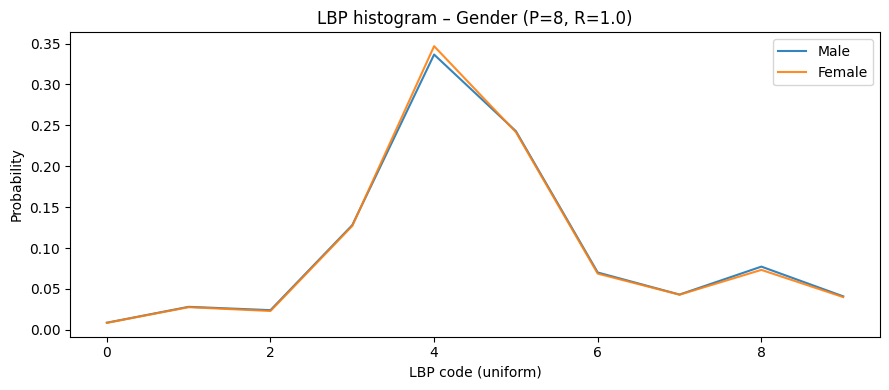

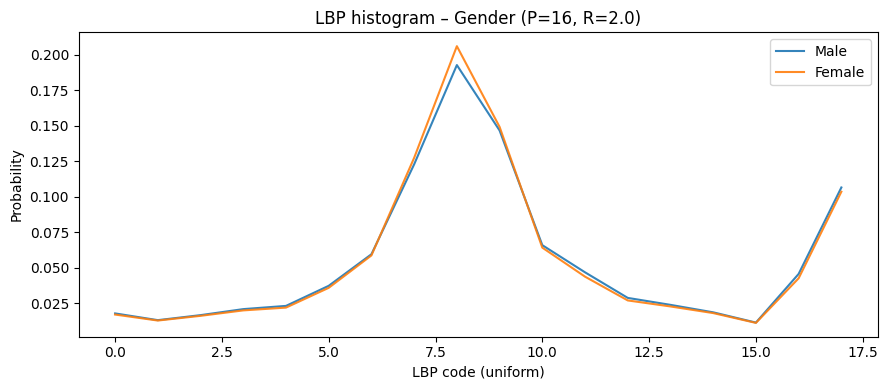

In [40]:
plot_lbp_by_group(gender_lbp, LBP_SETTINGS, "Gender", "lbp_by_gender")

Los histogramas LBP por género revelan similitudes entre hombres y mujeres en las características de textura, aunque con diferencias cuantitativas sutiles. En la configuración P=8, ambas curvas muestran el pico masivo en el código 4, con la curva masculina (azul) alcanzando aproximadamente 0.35 y la femenina (naranja) llegando a cerca de 0.33. Esta diferencia del 6% sugiere que los rostros masculinos tienen una concentración ligeramente mayor de texturas suaves uniformes, posiblemente reflejando diferencias en la textura de la piel o en las condiciones de captura. Las curvas se superponen casi perfectamente en los códigos 0-3 y 5-9, indicando distribuciones similares de otros patrones de textura. En la configuración P=16, ambas curvas muestran nuevamente gran similitud, con picos en el código 8 de aproximadamente 0.20 para hombres y 0.19 para mujeres. Sin embargo, hay una diferencia notable en el código 17 (patrones no uniformes) porque la curva femenina alcanza aproximadamente 0.11 mientras que la masculina llega a cerca de 0.10. Esta inversión de la jerarquía observada en P=8 sugiere que aunque los rostros masculinos tienen más texturas uniformes a escala pequeña, los rostros femeninos muestran mayor complejidad textural a escalas mayores. Esto podría relacionarse con características como maquillaje que añade microestructuras finas pero perceptibles a escala mayor, o diferencias en la presentación fotográfica como el cabello largo que introduce mayor variabilidad textural en el encuadre.


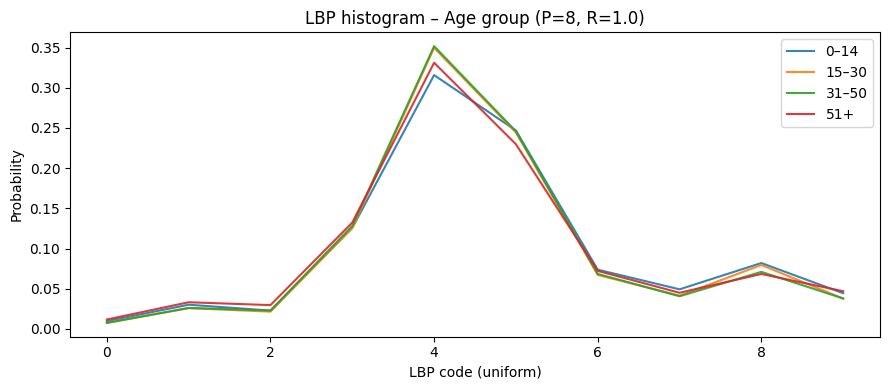

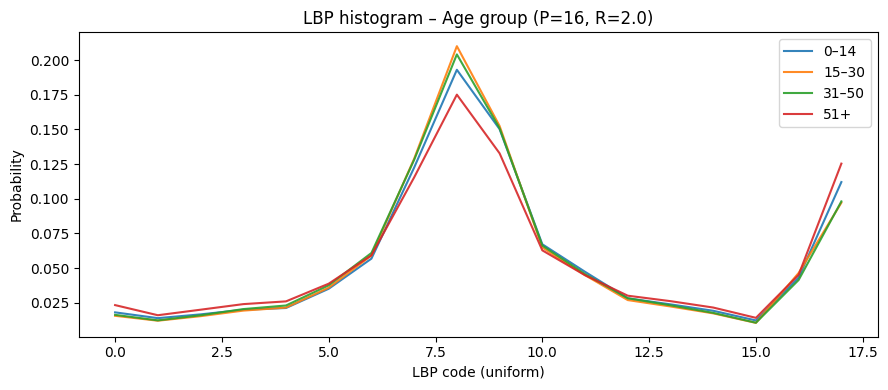

In [41]:
plot_lbp_by_group(age_lbp,    LBP_SETTINGS, "Age group", "lbp_by_age")


Los histogramas LBP por grupo de edad muestran un comportamiento muy similar, en la configuración P=8 las cuatro curvas se superponen casi perfectamente en el pico dominante del código 4, con todos los grupos alcanzando probabilidades entre 0.32 y 0.35. El grupo 31-50 (verde) muestra el pico ligeramente más alto (aproximadamente 0.35), seguido muy de cerca por 0-14 (azul) y 15-30 (naranja) con cerca de 0.33, y finalmente 51+ (rojo) con aproximadamente 0.32. Estas diferencias del orden del 10% son modestas y sugieren que la textura dominante de la piel facial permanece notablemente constante a través del ciclo de vida. Las curvas se mantienen prácticamente indistinguibles en todos los demás códigos, con superposición completa en los códigos 0-3 y 5-9. En la configuración P=16, el patrón de convergencia se mantiene pero con una variabilidad ligeramente mayor. Los cuatro grupos muestran picos en el código 8 con probabilidades entre 0.18 y 0.21, con 31-50 nuevamente mostrando el valor más alto. El código 17 muestra mayor separación entre grupos puesto que el grupo 51+ alcanza aproximadamente 0.13, notablemente más alto que los otros grupos que se mantienen alrededor de 0.10. Este aumento en patrones no uniformes para adultos mayores podría reflejar cambios en la textura de la piel asociados con el envejecimiento, como arrugas, manchas, o cambios en la microtopografía facial que introducen mayor complejidad textural a escalas mayores.


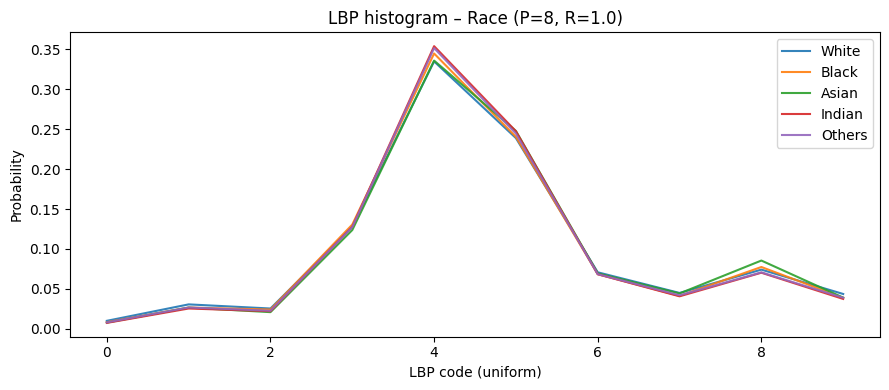

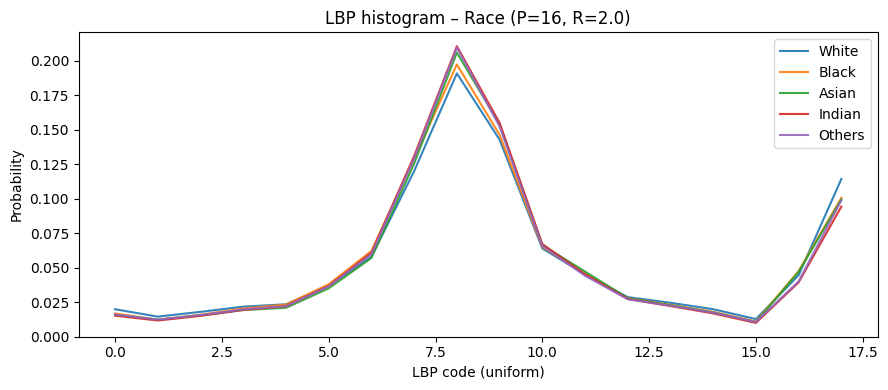

In [42]:
plot_lbp_by_group(race_lbp,   LBP_SETTINGS, "Race", "lbp_by_race")

Los histogramas LBP por raza presentan el análisis más revelador sobre diferencias en textura facial entre grupos demográficos. En la configuración P=8, todas las cinco curvas convergen hacia el mismo pico en el código 4, pero con una jerarquía clara en las alturas: el grupo asiático (verde) alcanza el pico más alto de aproximadamente 0.35, seguido por negro (naranja) con cerca de 0.34, luego blanco (azul) con aproximadamente 0.33, "Others" (púrpura) con cerca de 0.32, e indio (rojo) con el pico más bajo de aproximadamente 0.31. Esta jerarquía sugiere que la piel asiática y negra, a pesar de sus diferencias dramáticas en luminosidad, comparten una característica común: mayor uniformidad textural a escala pequeña. Esto podría reflejar propiedades físicas de la piel como menor visibilidad de poros o vascularización superficial. El grupo indio muestra el pico más bajo, sugiriendo mayor heterogeneidad textural, consistente con la mayor diversidad de tonos de piel dentro de este grupo. Las curvas se superponen considerablemente en los otros códigos, aunque con pequeñas diferencias: los códigos 5-6 muestran valores ligeramente más altos para el grupo indio, y el código 9 (no uniformes) es comparable en todos los grupos alrededor de 0.04-0.05. En la configuración P=16, los patrones se vuelven más complejos y revelan diferencias más pronunciadas entre razas. El pico en el código 8 muestra una jerarquía similar pero con mayor separación porque el grupo asiático alcanza aproximadamente 0.21, negro cerca de 0.20, blanco alrededor de 0.19, "Others" cerca de 0.18, e indio aproximadamente 0.17. La mayor separación en esta escala mayor sugiere que las diferencias texturales entre razas se amplifican cuando se muestrean vecindarios más grandes.


El código 17 en la configuración P=16 revela diferencias raciales particularmente interesantes en texturas complejas. El grupo blanco muestra el pico más alto en este código, alcanzando aproximadamente 0.12, seguido por "Others" con cerca de 0.11, luego indio con aproximadamente 0.10, asiático con cerca de 0.095, y finalmente negro con el valor más bajo de aproximadamente 0.09. Esta jerarquía es casi inversa a la observada en el código 8, sugiriendo un trade-off, los grupos con mayor uniformidad textural (asiático, negro) tienen menos patrones complejos, mientras que los grupos con menor uniformidad en el código dominante (blanco, "Others") compensan con mayor presencia de texturas complejas. Esta dicotomía podría reflejar diferencias reales en la microestructura de la piel (como visibilidad de poros, vascularización superficial, o características de vello facial fino) o diferencias en las condiciones de captura fotográfica y procesamiento que afectan la percepción de textura. Para el grupo blanco específicamente, la mayor presencia de patrones no uniformes podría relacionarse con mayor visibilidad de características dérmicas debido a la menor cantidad de melanina que actúa como un "difusor óptico" natural en pieles más oscuras.



Comparando todas las gráficas LBP en conjunto, concluímos que, existe un patrón de textura dominante universal (código 4 en P=8, código 8 en P=16) que representa más del 20-35% de todos los píxeles independientemente del grupo demográfico, confirmando que la piel facial humana tiene una microestructura característica común. Segundo, las diferencias de género en textura son mínimas, mucho menores que las diferencias en color, sugiriendo que las características texturales son relativamente invariantes al género. Tercero, las diferencias de edad son sorprendentemente pequeñas en la escala fina (P=8) pero se vuelven más pronunciadas en la escala mayor (P=16), especialmente para adultos mayores que muestran mayor complejidad textural, consistente con los cambios dermatológicos asociados con el envejecimiento. Cuarto, las diferencias raciales en textura son sistemáticas y revelan un patrón complejo donde algunos grupos (asiático, negro) muestran mayor uniformidad mientras otros (blanco, indio) muestran mayor heterogeneidad, lo cual no correlaciona simplemente con las diferencias en pigmentación. Quinto, la configuración P=16 es más discriminativa que P=8, capturando diferencias que no son evidentes a escalas pequeñas. Finalmente, la presencia relativamente baja de patrones no uniformes en todos los grupos (10-13% en P=16) confirma que el dataset contiene imágenes de buena calidad con niveles moderados de ruido. Para aplicaciones de visión por computadora, estos hallazgos sugieren que las características LBP podrían ser útiles para clasificación racial y detección de envejecimiento, aunque son menos informativas para clasificación de género. La invariancia relativa de LBP a cambios de iluminación lo hace un complemento valioso a las características de color que son más sensibles a condiciones de captura.

**Conclusión**

El análisis demuestra que la edad produce cambios sistemáticos y dramáticos en múltiples características visuales, lo cual es esencial para un sistema de reconocimiento efectivo. Los histogramas RGB muestran que el grupo infantil (0-14 años) es claramente distinguible de todos los demás grupos, con distribuciones de color fuertemente desplazadas hacia valores altos, especialmente en el canal rojo donde forman picos únicos alrededor de 220. Esta separabilidad extrema sugiere que la clasificación de niños versus adultos debería ser relativamente sencilla usando características de color. Los histogramas de escala de grises confirman este patrón, mostrando que los niños tienen distribuciones de luminosidad consistentemente más altas que todos los grupos adultos. Las características de color capturan efectivamente las propiedades ópticas de la piel infantil (mayor translucidez, vascularización visible) que son fundamentalmente diferentes de la piel adulta, proporcionando señales discriminativas robustas.

Para la distinción entre grupos adultos, el dataset también muestra promesa aunque con desafíos mayores. Los grupos 31-50 y 51+ presentan diferencias sutiles pero consistentes en los histogramas RGB y de luminosidad, con los adultos mayores mostrando distribuciones ligeramente más desplazadas hacia valores medios-bajos y mayor aplanamiento de picos. Crucialmente, los histogramas LBP con P=16 revelan que los adultos mayores exhiben mayor proporción de patrones texturales complejos (código 17 alcanza aproximadamente 0.13 versus 0.10 en otros grupos adultos), lo cual es consistente con cambios dermatológicos asociados al envejecimiento como arrugas y alteraciones en la microtopografía facial. Esta separabilidad en el espacio textural complementa las señales de color, sugiriendo que un enfoque multimodal que combine características cromáticas y texturales podría lograr clasificación efectiva de edad en adultos.

Concluímos que el dataset es útil y contiene señales discriminativas de edad, especialmente para las categorías infantil y para cambios texturales en adultos mayores, pero requiere manejo cuidadoso de sus limitaciones, validación rigurosa contra confundidores, y posiblemente complementación con otras características más allá de color y textura básica para lograr clasificación de edad robusta y generalizable en el espectro completo de edades adultas.